 <h1 style="text-align: center;"> Анализ данных донаторов благотворительной оргнизации    "Марафон Добра"</h1>

**Цель проекта:** провести аналитическое исследование исторических данных о пожертвованиях, определить ключевые закономерности поведения донаторов, оценить эффективность регулярных подписок и сформулировать практические рекомендации для увеличения объема регулярных пожертвований и удержания донаторов.

**Задачи:**
1) Выполнить исследовательский анализ данных (EDA).
2) Рассчитать основные бизнес-показатели фонда.
3) Проанализировать динамику показателей во времени.
4) Выполнить RFM-анализ, сегментировать донаторов, описать характеристики каждого сегмента и предложить стратегии взаимодействия.
5) Провести когортный анализ по месяцу первого пожертвования. Построить матрицу удержания (Retention Matrix), оценить удержание различных когорт и сравнить их жизненный цикл.
6) Исследовать подписки (долю регулярных пожертвований, среднюю длительность подписки, распределение срока жизни подписок, уровень оттока, среднее количество платежей на подписчика). 
7) Провести Survival Analysis (анализ выживаемости подписок).
8) Проанализировать переход пользователей от разовых пожертвований к регулярным подпискам, определить конверсию и среднее время до перехода.
9) Рассчитать показатели (Retention, Churn Rate, Lifetime Value (LTV)).
10) Выполнить ABC-анализ и Pareto-анализ, определить вклад крупнейших донаторов в общий объем пожертвований.
11) Исследовать повторные пожертвования, интервалы между платежами и жизненный цикл донатора.
12) Подготовить интерактивный аналитический дашборд с основными KPI, графиками динамики, когортами, RFM-сегментами, анализом подписок 
и результатами Survival Analysis.
13) Сформулировать практические рекомендации для фонда.

Одна строка = подписка (не платёж).

Данные предоставлены за период за 08.04.2019 – 18.06.2026.


## 1. Загрузка данных и знакомство с ними

In [1]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import datetime as dt
from datetime import datetime, timedelta
from statsmodels.tsa.seasonal import seasonal_decompose
!pip install lifelines
from lifelines import KaplanMeierFitter
from scipy.interpolate import interp1d

In [2]:
df = pd.read_csv('encoded_Подписки Cloud Payments 18-06.csv', sep = ';')

In [3]:
df.head()

,ID,Дата/время создания,Статус,Сумма,Валюта,Периодичность,Описание,ID плательщика,Кол-во платежей,Дата/время последнего платежа,Дата/время следующего платежа
0,sc_5fd0defafe7ff468dbd3257da445c,18.06.2026 08:39:25,Активна,"1000,00",₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_41ef2e0fdbe2,0,NaN,18.07.2026 08:39:24
1,sc_fb4115049bb199106b401cb66c8bb,17.06.2026 20:57:39,Активна,"100,00",₽,Раз в месяц,Благотворительное пожертвование,PID_34f44fc59dc0,0,NaN,17.07.2026 20:57:39
2,sc_1dad551bda204a1c1ce3a60573458,17.06.2026 20:35:25,Активна,"100,00",₽,Раз в месяц,Благотворительное пожертвование,PID_1070551ebf1b,0,NaN,17.07.2026 20:35:25
3,sc_9c512c6a7880f7cceb309c654c7ef,16.06.2026 20:37:05,Активна,"500,00",₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_cd9879f83789,0,NaN,16.07.2026 20:37:05
4,sc_b1911b7fb5bd247c6c40f25707aed,16.06.2026 15:43:23,Активна,"100,00",₽,Раз в месяц,Благотворительное пожертвование. Ежемесячная п...,PID_6bf236df9e02,0,NaN,16.07.2026 15:43:22


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42806 entries, 0 to 42805
Data columns (total 11 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   ID                             42806 non-null  object
 1   Дата/время создания            42806 non-null  object
 2   Статус                         42806 non-null  object
 3   Сумма                          42806 non-null  object
 4   Валюта                         42806 non-null  object
 5   Периодичность                  42806 non-null  object
 6   Описание                       42806 non-null  object
 7   ID плательщика                 42806 non-null  object
 8   Кол-во платежей                42806 non-null  int64 
 9   Дата/время последнего платежа  28537 non-null  object
 10  Дата/время следующего платежа  6528 non-null   object
dtypes: int64(1), object(10)
memory usage: 3.6+ MB


In [5]:
# Создаем копию датасета до преобразования для возможности проверить сделанные изменения после предобработки
temp = df.copy() 
len(temp)

42806

In [6]:
df['Статус'].value_counts()

Статус
Отменена      19259
Отклонена     17025
Активна        4827
Просрочена     1643
В ожидании       52
Name: count, dtype: int64

### Промежуточный вывод

Датасет 'encoded_Подписки Cloud Payments 18-06.csv' содержит 11 столбцов и 42806 строк, в которых представлена информация о платежах донаторов благотворительного фонда.

После первичного анализа данных можно сделать следующие выводы:

Названия столбцов лучше привести к одному виду, например, snake case. Все представленные данные содержат числовые значения и текстовые, хранятся в типах данных int64 и  object. Тип данных Дата/время создания, Сумма, Дата/время последнего платежа и Дата/время следующего платежа не соответствуют логическому типу данных, следует поменять на соответствующий. Пропуски содержатся в столбцах Дата/время последнего платежа и Дата/время следующего платежа, их следует пропустить. 

## 2. Предобработка данных

In [7]:
# Перечень столбцов, которые должны иметь тип данных даты и времени
numeric_columns = ['Дата/время создания','Дата/время последнего платежа','Дата/время следующего платежа']

In [8]:
# Преобразование типов данных и замена всех значений на NaN, которые не удалось преобразовать в тип данных даты и времени
for column in numeric_columns:
    df[column]= pd.to_datetime(df[column],errors='coerce', format='%d.%m.%Y %H:%M:%S')

In [9]:
df['Сумма'].unique()[:20] 

array(['1000,00', '100,00', '500,00', '5000,00', '2000,00', '200,00',
       '300,00', '48,00', '10,00', '800,00', '525,00', '1500,00',
       '700,00', '51,00', '78,00', '90,00', '70,00', '60,00', '67,00',
       '75,00'], dtype=object)

In [10]:
if df['Сумма'].dtype == 'object':
    df['Сумма'] = df['Сумма'].str.replace(',', '.').str.replace(' ', '').str.rstrip('.').astype(float)
else:
    print("Столбец уже числовой, преобразование не требуется.")

In [11]:
# Проверим тип данных
df[['Дата/время создания','Дата/время последнего платежа','Дата/время следующего платежа','Сумма']].dtypes

Дата/время создания              datetime64[ns]
Дата/время последнего платежа    datetime64[ns]
Дата/время следующего платежа    datetime64[ns]
Сумма                                   float64
dtype: object

In [12]:
# Проверяем пропуски
df.isna().sum()

ID                                   0
Дата/время создания                  0
Статус                               0
Сумма                                0
Валюта                               0
Периодичность                        0
Описание                             0
ID плательщика                       0
Кол-во платежей                      0
Дата/время последнего платежа    14269
Дата/время следующего платежа    36278
dtype: int64

In [13]:
# Доля пропусков
df.isna().mean()

ID                               0.000000
Дата/время создания              0.000000
Статус                           0.000000
Сумма                            0.000000
Валюта                           0.000000
Периодичность                    0.000000
Описание                         0.000000
ID плательщика                   0.000000
Кол-во платежей                  0.000000
Дата/время последнего платежа    0.333341
Дата/время следующего платежа    0.847498
dtype: float64

In [14]:
# Проверим наименование столбцов датафрейма
df.columns

Index(['ID', 'Дата/время создания', 'Статус', 'Сумма', 'Валюта',
       'Периодичность', 'Описание', 'ID плательщика', 'Кол-во платежей',
       'Дата/время последнего платежа', 'Дата/время следующего платежа'],
      dtype='object')

In [15]:
# Приведим все столбцы к стилю snake case
df.columns = df.columns.str.lower().str.strip().str.replace(' ', '_')

In [16]:
df.columns

Index(['id', 'дата/время_создания', 'статус', 'сумма', 'валюта',
       'периодичность', 'описание', 'id_плательщика', 'кол-во_платежей',
       'дата/время_последнего_платежа', 'дата/время_следующего_платежа'],
      dtype='object')

In [17]:
# Нормализация данных
df['статус'] = df['статус'].astype(str).str.lower().str.strip().str.replace(' ', '_')


In [18]:
df['валюта'] = df['валюта'].astype(str).str.lower().str.strip().str.replace(' ', '_')


In [19]:
df['описание'] = df['описание'].astype(str).str.lower().str.strip().str.replace(' ', '_')


In [20]:
# Проверяем полные дубликаты 
df.duplicated().sum()

np.int64(0)

Полных дубликатов нет.

In [21]:
# Проверяем неявные дубликаты в датафрейме 
df.duplicated(subset='id').sum()

np.int64(0)

Неявных дубликатов тоже нет.

In [22]:
# Определим основные статпоказатели
df[['сумма','кол-во_платежей']].describe()

,сумма,кол-во_платежей
count,42806.000000,42806.000000
mean,338.585660,5.566439
std,1259.889751,9.591057
min,1.000000,0.000000
25%,100.000000,0.000000
50%,200.000000,1.000000
75%,500.000000,6.000000
max,200000.000000,85.000000


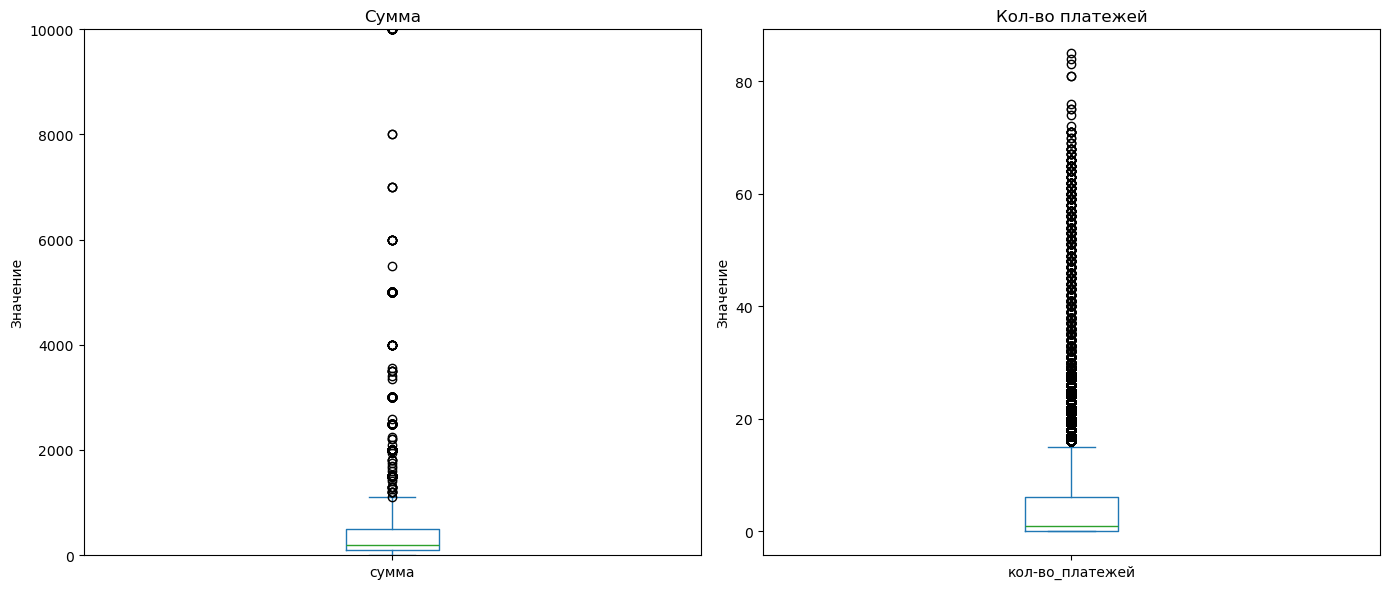

In [23]:
# Определим наличие/отсутствие выбросов, используя диаграмму размаха

fig, axes = plt.subplots(1, 2, figsize=(14, 6))  # две оси, общий размер

# Первый график — сумма
df[['сумма']].plot.box(ax=axes[0])
axes[0].set_title('Сумма')
axes[0].set_ylabel('Значение')
axes[0].set_ylim(0, 10000)

# Второй график — кол-во платежей
df[['кол-во_платежей']].plot.box(ax=axes[1])
axes[1].set_title('Кол-во платежей')
axes[1].set_ylabel('Значение')

plt.tight_layout() 
plt.show()

In [24]:
# Определим выбросы и удалим их
Q1_sum = df['сумма'].quantile(0.25)
Q3_sum = df['сумма'].quantile(0.75)
IQR_sum = Q3_sum - Q1_sum

Q1_cnt = df['кол-во_платежей'].quantile(0.25)
Q3_cnt = df['кол-во_платежей'].quantile(0.75)
IQR_cnt = Q3_cnt - Q1_cnt

# Фильтруем по обоим условиям
df_clean = df[
    (df['сумма'] >= Q1_sum - 1.5 * IQR_sum) &
    (df['сумма'] <= Q3_sum + 1.5 * IQR_sum) &
    (df['кол-во_платежей'] >= Q1_cnt - 1.5 * IQR_cnt) &
    (df['кол-во_платежей'] <= Q3_cnt + 1.5 * IQR_cnt)
]
print(f"Удалено {len(df) - len(df_clean)} строк с выбросами")
print(f"Осталось {len(df_clean)} строк")

Удалено 5909 строк с выбросами
Осталось 36897 строк


In [25]:
# Проверим наименование столбцов датафрейма
df.columns

Index(['id', 'дата/время_создания', 'статус', 'сумма', 'валюта',
       'периодичность', 'описание', 'id_плательщика', 'кол-во_платежей',
       'дата/время_последнего_платежа', 'дата/время_следующего_платежа'],
      dtype='object')

In [26]:
# Находим выбросы по сумме
Q1 = df['сумма'].quantile(0.25)
Q3 = df['сумма'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = df[df['сумма'] > upper]

# Смотрим на их характеристики
print("Количество выбросов:", len(outliers))
print("Доля от всех записей:", len(outliers) / len(df) * 100, "%")
print("Сумма выбросов составляет:", outliers['сумма'].sum() / df['сумма'].sum() * 100, "% от общей суммы")

# Проверяем статусы выбросов
print(outliers['статус'].value_counts())

# Проверяем периодичность
print(outliers['периодичность'].value_counts())

# Смотрим на ID плательщиков
print(outliers['id'].value_counts().head(10))

Количество выбросов: 845
Доля от всех записей: 1.9740223333177591 %
Сумма выбросов составляет: 20.95354790194752 % от общей суммы
статус
отменена      405
отклонена     224
активна       163
просрочена     53
Name: count, dtype: int64
периодичность
Раз в месяц    845
Name: count, dtype: int64
id
sc_6ea06a94c3b342b0f54cbb1b3d357    1
sc_98af8b64be9731c29ec8da11ac1b3    1
sc_67597f606ac61ee2eb7f62497b861    1
sc_417c16f783537942638024d61cbea    1
sc_f88b9bd477d8532209f030d85bf06    1
sc_9f718073c2927ce9cbe27ae4c67db    1
sc_6fa0e6e2dd8f0634f164b8c9e2a1d    1
sc_d4afd3c4aa84e7241adf0a819b449    1
sc_917e2e046afa49d25053cbc1fcc1d    1
sc_fcde2a20122e08a5c635747491e02    1
Name: count, dtype: int64


Поскольку все 845 выбросов имеют логичные статусы (активные, отменённые, просроченные), у них реальные ID плательщиков и ни один ID не повторяется (это разные донаторы, а не дубликаты), по всей вероятности, данные не являются выбросами и необходимы при дальнейшем анализе. 2 % крупных донатеров приносят 20 % крупных взносов. Но мы видим существующую проблему в виде удержания крупных донатеров, причину чего необходимо определить.

### Промежуточный вывод

В ходе анализа данных были выявлены пропуски в столбцах «Дата/время последнего платежа» (33,3 %) и «Дата/время следующего платежа» (84,7 %), их не удаляли. Все названия столбцов датафрейма мы привели к стилю snake case, столбец «Сумма» — к числовому типу данных с плавающей запятой, а столбцы «Дата/время последнего платежа» и «Дата/время следующего платежа» — к типу данных «дата и время». Определили количество полных и неполных дубликатов в датафреймах, их не оказалось. Таким образом, данные можно анализировать. Их достаточно для решения задач проекта.

## 3. Исследовательский анализ данных.

# 3.1. Рассчитаем основные бизнес-показатели фонда.

In [27]:
df.head()

,id,дата/время_создания,статус,сумма,валюта,периодичность,описание,id_плательщика,кол-во_платежей,дата/время_последнего_платежа,дата/время_следующего_платежа
0,sc_5fd0defafe7ff468dbd3257da445c,2026-06-18 08:39:25,активна,1000.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_41ef2e0fdbe2,0,NaT,2026-07-18 08:39:24
1,sc_fb4115049bb199106b401cb66c8bb,2026-06-17 20:57:39,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование,PID_34f44fc59dc0,0,NaT,2026-07-17 20:57:39
2,sc_1dad551bda204a1c1ce3a60573458,2026-06-17 20:35:25,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование,PID_1070551ebf1b,0,NaT,2026-07-17 20:35:25
3,sc_9c512c6a7880f7cceb309c654c7ef,2026-06-16 20:37:05,активна,500.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_cd9879f83789,0,NaT,2026-07-16 20:37:05
4,sc_b1911b7fb5bd247c6c40f25707aed,2026-06-16 15:43:23,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_6bf236df9e02,0,NaT,2026-07-16 15:43:22


**Обозначение статусов подписки**:
    
- «Просрочена» (PastDue) — одна или две неудачные попытки списания подряд. Подписка еще активна, система пробует снова.
- «Отклонена» (Rejected) — три неудачные попытки подряд. Подписка окончательно остановлена.
- «Отменена» (Cancelled) — только отмена по запросу: фонда или самого донора.
- «Завершена» (Expired) — все периоды истекли (в данных не встречается — подписки фонда бессрочные).

При недостатке денег на карте: активна → просрочена (1–2 сбоя) → отклонена (3-й сбой). 

Статус «Отменена» — всегда отмена по запросу.

Статус «В ожидании»: предположительно, статус транзакции «Ожидает аутентификации» — плательщик ушёл на 3-D Secure, и результат не пришёл; относится к уровню платежа, а не подписки.

In [28]:
# Общая статистика по донаторам
print("Статистика по донаторам")
print(f"Всего уникальных плательщиков: {df['id_плательщика'].nunique()}")
print(f"Из них с платежами (>0): {df[df['кол-во_платежей'] > 0]['id_плательщика'].nunique()}")
print(f"Активных подписок: {df[df['статус'] == 'активна']['id_плательщика'].nunique()}")
print(f"Отменённых/завершённых: {df[df['статус'].isin(['завершена', 'отменена'])]['id_плательщика'].nunique()}")

Статистика по донаторам
Всего уникальных плательщиков: 31105
Из них с платежами (>0): 21864
Активных подписок: 4176
Отменённых/завершённых: 15013


In [29]:
# Количество платежей
total_payments = df['кол-во_платежей'].sum()
print(f"Всего платежей по всем подпискам: {total_payments:,}")

Всего платежей по всем подпискам: 238,277


In [30]:
# Общий объем пожертвований
total_revenue = (df['сумма'] * df['кол-во_платежей']).sum()
print("Общий объём пожертвований")
print(f"Всего: {total_revenue:,.2f} руб.")

Общий объём пожертвований
Всего: 74,129,253.82 руб.


In [31]:
# Средний и медианный чек
# Размножаем строки по числу платежей
expanded = df.loc[df.index.repeat(df['кол-во_платежей'])]

avg_check = expanded['сумма'].mean()
median_check = expanded['сумма'].median()

print(f"Средний чек: {avg_check:.2f} руб.")
print(f"Медианный чек: {median_check:.2f} руб.")

Средний чек: 311.11 руб.
Медианный чек: 200.00 руб.


In [32]:
# Средняя сумма пожертвований (средняя сумма подписки) по месяцам 

df['месяц'] = df['дата/время_создания'].dt.month

# Статистика по месяцам
monthly_stats = df.groupby('месяц').agg(
    Количество=('сумма', 'count'),
    Средняя=('сумма', 'mean'),
    Медиана=('сумма', 'median'),
    Общая_сумма=('сумма', 'sum')
).round(2)

monthly_stats

,Количество,Средняя,Медиана,Общая_сумма
месяц,,,,
1,4530,362.25,200.0,1640971.00
2,3682,319.32,200.0,1175754.00
3,3016,316.19,200.0,953625.00
4,3282,340.40,200.0,1117209.00
5,3257,355.05,200.0,1156410.00
6,3545,328.04,200.0,1162918.00
7,3928,392.31,200.0,1540998.00
8,2892,332.02,200.0,960193.00
9,2756,317.53,200.0,875126.32


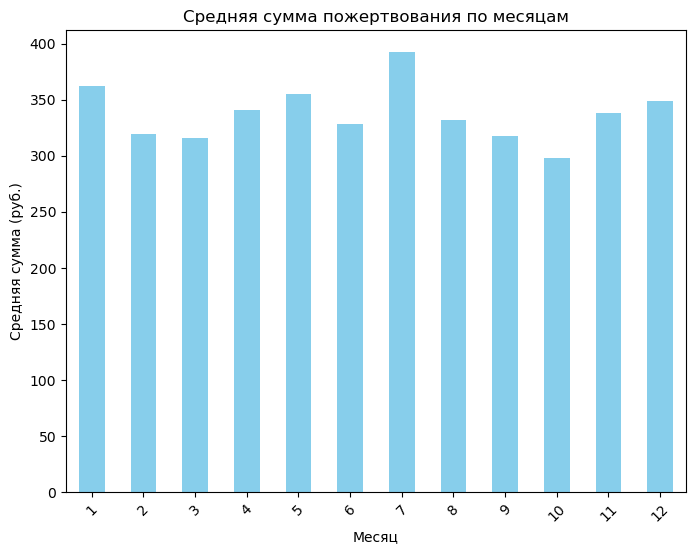

In [33]:
# График
monthly_stats['Средняя'].plot(kind='bar', figsize=(8,6), color='skyblue')
plt.xticks(rotation=45)
plt.title('Средняя сумма пожертвования по месяцам')
plt.ylabel('Средняя сумма (руб.)')
plt.xlabel('Месяц')
plt.show()

In [34]:
# Количество активных донаторов
active_donors = df[df['статус'] == 'активна']['id_плательщика'].nunique()
print(f"Активных донаторов: {active_donors}")

Активных донаторов: 4176


In [35]:
# Количество новых донаторов

In [36]:
# Первая подписка каждого донатора
first_sub = df.groupby('id_плательщика')['дата/время_создания'].min().reset_index()
first_sub.columns = ['ID плательщика', 'Дата первого оформления']

# Новые за последний месяц
today = datetime.now()
last_month = today - timedelta(days=30)
new_donors = first_sub[first_sub['Дата первого оформления'] >= last_month]['ID плательщика'].nunique()
print(f"Новых донаторов за последние 30 дней: {new_donors}")

# Динамика по месяцам
first_sub['Месяц'] = first_sub['Дата первого оформления'].dt.to_period('M')
new_by_month = first_sub.groupby('Месяц')['ID плательщика'].nunique()
print("\nНовые донаторы по месяцам:")
print(new_by_month)

Новых донаторов за последние 30 дней: 0

Новые донаторы по месяцам:
Месяц
2019-04    510
2019-05    412
2019-06    315
2019-07    510
2019-08    294
          ... 
2026-02    165
2026-03    102
2026-04    111
2026-05    107
2026-06     45
Freq: M, Name: ID плательщика, Length: 87, dtype: int64


### Промежуточный вывод

Из полученных данных, можем наблюдать несколько проблем:
- высокий отток донаторов (примерно 81 %),
- 30 % несостоявшихся подписок,
- падение количества новых донатеров в 2026 году,
- сезонные спады (март, август, сентябрь).

В данной ситуации необходимо удержание и поощрение существующих пожервователей, повышение конверсии из оформления в оплату, а так же проведение сезонных кампаний и привлечение новых донатеров через новые каналы.

# 3.2. Проанализируем накомпленную ценность подписок по месяцу привлечения.

Мы рассмотрим накомпленную ценность подписок по месяцу привлечения. Показатель отражает суммарный доход, который подписки, созданные в каждом месяце, принесли за всё время наблюдения. Он не является реальной месячной выручкой фонда.

In [37]:
df['Объем_пожертвований'] = df['сумма'] * df['кол-во_платежей']

# Группируем по месяцу создания подписки
df['Год_месяц'] = df['дата/время_создания'].dt.to_period('M')

monthly_real = df.groupby('Год_месяц').agg(
    total_revenue=('Объем_пожертвований', 'sum'),
    count=('сумма', 'count'),
    avg_revenue=('Объем_пожертвований', 'mean')
).reset_index()

monthly_real['Год_месяц'] = monthly_real['Год_месяц'].dt.to_timestamp()

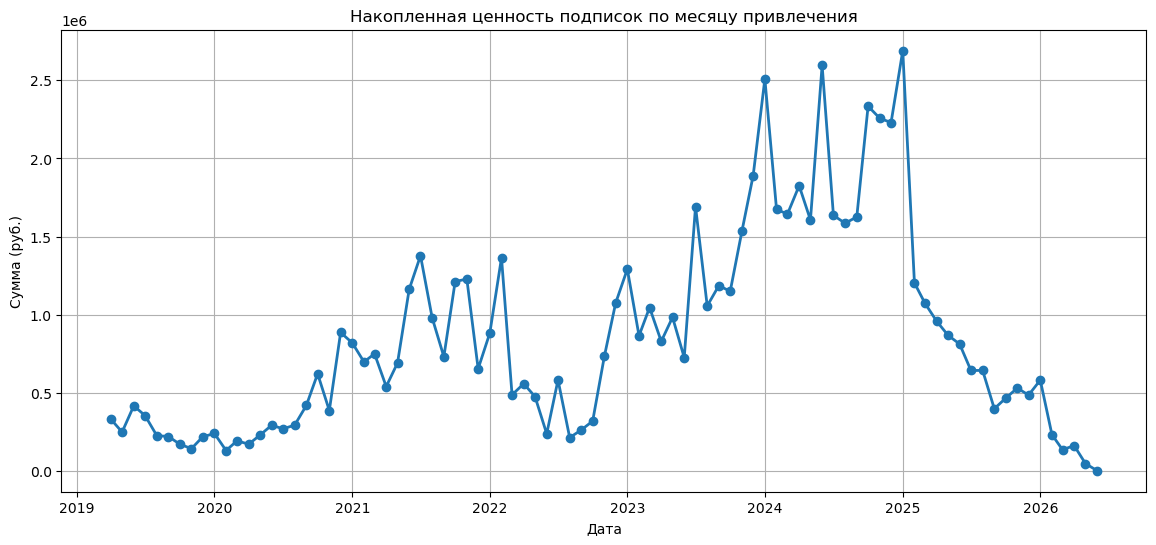

In [38]:
# Визуализируем
plt.figure(figsize=(14,6))
plt.plot(monthly_real['Год_месяц'], monthly_real['total_revenue'], marker='o', linewidth=2)
plt.title('Накопленная ценность подписок по месяцу привлечения')
plt.xlabel('Дата')
plt.ylabel('Сумма (руб.)')
plt.grid(True)
plt.show()

Объем пожертвований:

2019 – 2022	Постепенный рост с отдельными пиками.

2023 – начало 2024 Активный рост, выход на плато.

2024 – 2026	Снижение, спад в 2025–2026 (Критический сигнал!).


In [39]:
# Декомпозируем временной ряд

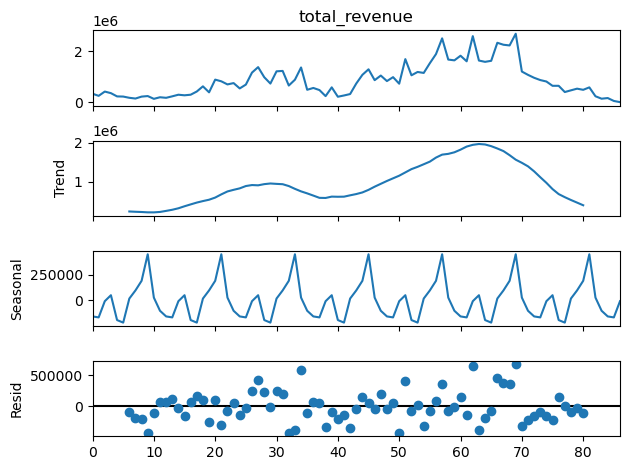

In [40]:
decomp = seasonal_decompose(monthly_real['total_revenue'], model='additive', period=12)
decomp.plot()
plt.show()

Мы наблюдаем нисходящий тренд для показатель объем пожертвований.    
Долгосрочный тренд — нисходящий с 2024 года.

Сезонность стабильна —  помогает планировать, но не спасает от общего спада.

Остатки не содержат аномалий — значит, падение не связано с разовыми факторами, а носит системный характер.    

In [41]:
# Рассмотрим темп роста
monthly_real['growth'] = monthly_real['total_revenue'].pct_change() * 100  # цепной в %
monthly_real['growth_cum'] = (monthly_real['total_revenue'] / monthly_real['total_revenue'].iloc[0] - 1) * 100 # базовый

print(monthly_real[['Год_месяц', 'growth', 'growth_cum']].tail(12))

    Год_месяц      growth  growth_cum
75 2025-07-01  -20.846140   94.158849
76 2025-08-01    0.063240   94.281636
77 2025-09-01  -38.180262   20.104399
78 2025-10-01   16.846625   40.337936
79 2025-11-01   14.123349   60.158353
80 2025-12-01   -8.537115   46.485450
81 2026-01-01   19.844537   75.554810
82 2026-02-01  -60.237321  -30.194705
83 2026-03-01  -41.570702  -59.213256
84 2026-04-01   19.023750  -51.454088
85 2026-05-01  -71.463191  -86.146546
86 2026-06-01 -100.000000 -100.000000


In [42]:
# Рассмотрим динамику количества платежей

In [43]:

payments_time = df.groupby('Год_месяц').agg(
    total_payments=('кол-во_платежей', 'sum'),
    avg_payments=('кол-во_платежей', 'mean'),
    median_payments=('кол-во_платежей', 'median'),
    max_payments=('кол-во_платежей', 'max'),
    count_subscriptions=('id_плательщика', 'count'),
    zero_payments=('кол-во_платежей', lambda x: (x == 0).sum())
).reset_index()

payments_time['Год_месяц'] = payments_time['Год_месяц'].dt.to_timestamp()

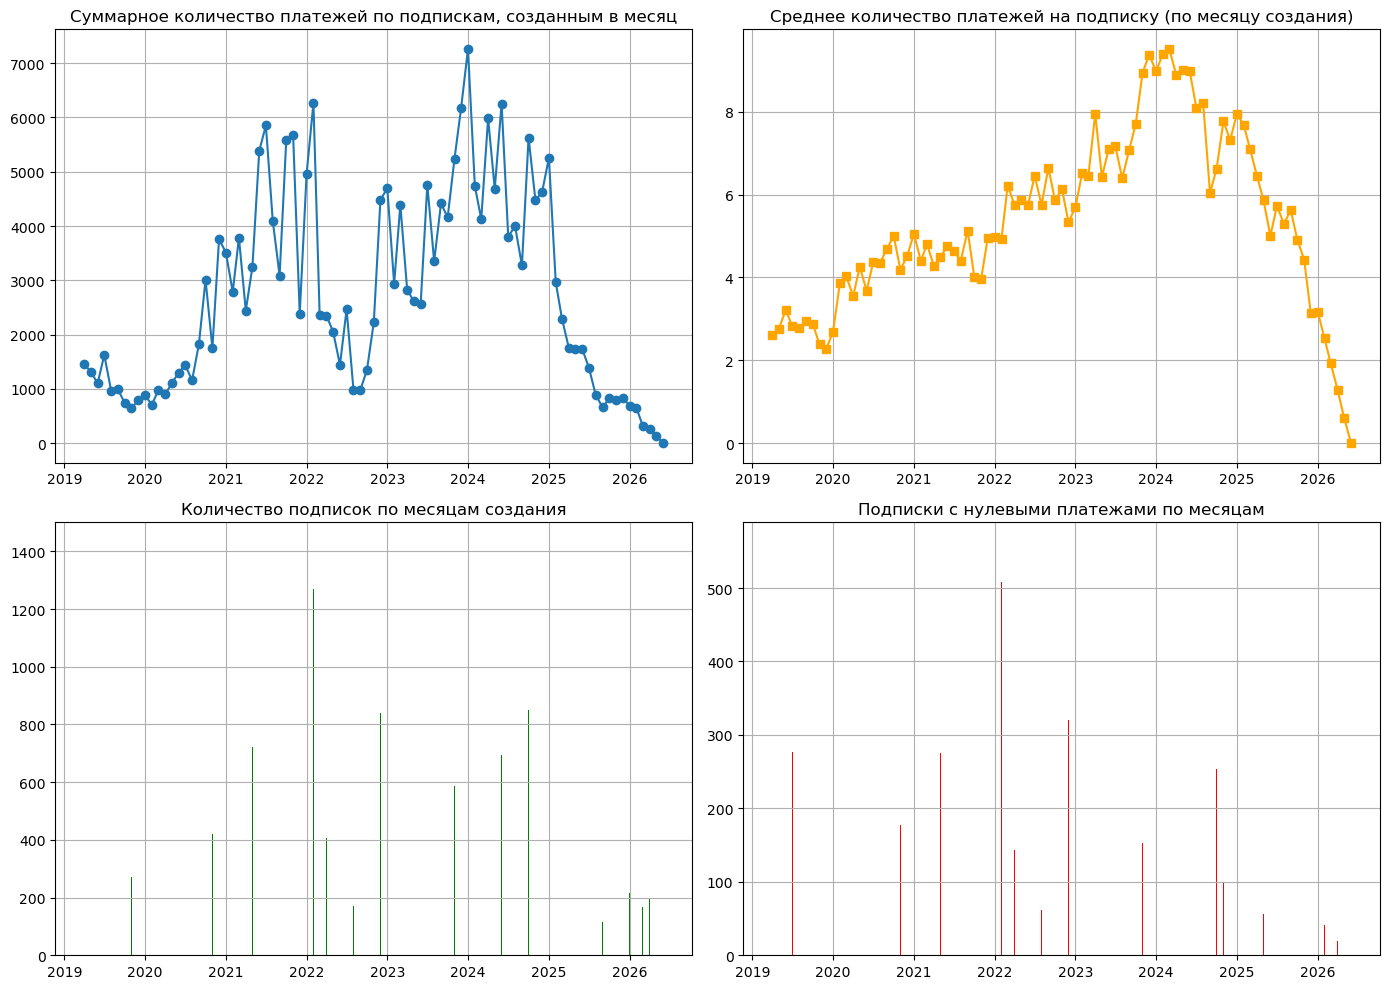

In [44]:
# Графики
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes[0, 0].plot(payments_time['Год_месяц'], payments_time['total_payments'], marker='o')
axes[0, 0].set_title('Суммарное количество платежей по подпискам, созданным в месяц')
axes[0, 0].grid(True)

axes[0, 1].plot(payments_time['Год_месяц'], payments_time['avg_payments'], marker='s', color='orange')
axes[0, 1].set_title('Среднее количество платежей на подписку (по месяцу создания)')
axes[0, 1].grid(True)

axes[1, 0].bar(payments_time['Год_месяц'], payments_time['count_subscriptions'], color='green')
axes[1, 0].set_title('Количество подписок по месяцам создания')
axes[1, 0].grid(True)

axes[1, 1].bar(payments_time['Год_месяц'], payments_time['zero_payments'], color='red')
axes[1, 1].set_title('Подписки с нулевыми платежами по месяцам')
axes[1, 1].grid(True)

plt.tight_layout()
plt.show()

Динамика количесва платежей:

Рост до середины 2023 года — пик суммарных платежей приходится на 2022–2023 годы.

Плато в 2024 году — значения стабилизируются на высоком уровне, но без дальнейшего роста.

Резкий спад с конца 2024 года — к 2026 году показатель падает до минимума (почти к нулю к июню 2026).

Среднее количество платежей на подписку:

В 2019–2020 среднее значение колеблется в районе 4–6 платежей.

2021–2023 — стабильные 5–7 платежей.

С 2024 года — устойчивое снижение до 2–3 платежей.

В 2025–2026 — падение до 1–2, а в последние месяцы — почти до 0.

Новые подписки стали «короче» — донаторы отписываются быстрее, чем раньше.


In [45]:
# Рассмотрим динамику среднего чека донаторов

In [46]:
df['real_revenue'] = df['сумма'] * df['кол-во_платежей']

df['Год_месяц'] = df['дата/время_создания'].dt.to_period('M')


avg_creation = df.groupby('Год_месяц').agg(
    total_revenue=('real_revenue', 'sum'),
    total_payments=('кол-во_платежей', 'sum')
).reset_index()

avg_creation['avg_check'] = avg_creation['total_revenue'] / avg_creation['total_payments']
avg_creation['Год_месяц'] = avg_creation['Год_месяц'].dt.to_timestamp()


print("Средний чек по месяцам создания")
print(avg_creation[['Год_месяц', 'avg_check']].tail(12))

Средний чек по месяцам создания
    Год_месяц   avg_check
75 2025-07-01  462.865177
76 2025-08-01  727.519819
77 2025-09-01  603.541033
78 2025-10-01  562.464242
79 2025-11-01  672.897078
80 2025-12-01  582.163462
81 2026-01-01  842.494920
82 2026-02-01  356.744977
83 2026-03-01  417.532508
84 2026-04-01  639.517928
85 2026-05-01  336.816176
86 2026-06-01         NaN


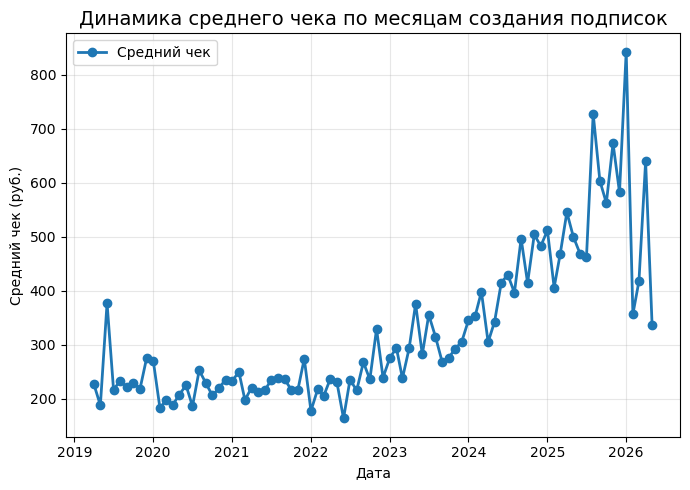

In [47]:
plt.figure(figsize=(7, 5))

plt.plot(
    avg_creation['Год_месяц'],
    avg_creation['avg_check'],
    marker='o',
    linewidth=2,
    label='Средний чек'
)

plt.title('Динамика среднего чека по месяцам создания подписок', fontsize=14)
plt.xlabel('Дата')
plt.ylabel('Средний чек (руб.)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

2019–2024: Средний чек стабилен и колеблется в диапазоне 250–380 руб. 

2024-2025: Небольшой рост среднего чека.

2026: Резкое падение — средний чек опускается почти до нуля. Это совпадает с общим спадом объёма пожертвований и количества платежей, который мы наблюдали ранее.

Средний чек не является проблемой — он оставался стабильным на протяжении многих лет. Проблема в количестве активных донаторов и платежей.

In [48]:
# Изучим сезонность

In [49]:
# Извлекаем месяц и год из даты создания
df['Месяц'] = df['дата/время_создания'].dt.month
df['Год'] = df['дата/время_создания'].dt.year
df['Год_месяц'] = df['дата/время_создания'].dt.to_period('M')

In [50]:
df['real_revenue'] = df['сумма'] * df['кол-во_платежей']

In [51]:
seasonal_profile = df.groupby('Месяц')['real_revenue'].mean().reset_index()
seasonal_profile.columns = ['Месяц', 'Средняя_сумма']

# Добавим названия месяцев
months = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн', 
          'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

seasonal_profile['Месяц_название'] = seasonal_profile['Месяц'].apply(lambda x: months[x-1])

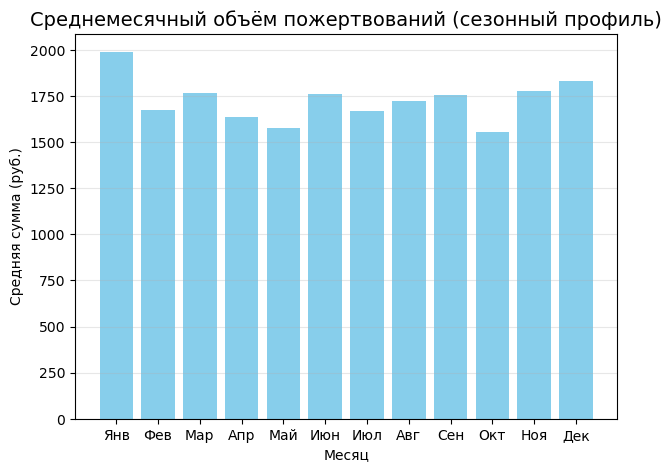

In [52]:
plt.figure(figsize=(7, 5))
plt.bar(seasonal_profile['Месяц_название'], seasonal_profile['Средняя_сумма'], color='skyblue')
plt.title('Среднемесячный объём пожертвований (сезонный профиль)', fontsize=14)
plt.xlabel('Месяц')
plt.ylabel('Средняя сумма (руб.)')
plt.grid(axis='y', alpha=0.3)
plt.show()

Подписки, созданные в январе, в среднем имеют более высокую накопленную ценность, чем подписки, созданные в другие месяцы. Это может быть связано с сезонностью привлечения, возрастными эффектами или составом донаторов. Для выделения истинной сезонности пожертвований необходимы данные о датах отдельных платежей.

In [53]:
# Темпы роста во времени

In [54]:
df['real_revenue'] = df['сумма'] * df['кол-во_платежей']

df['Год_месяц'] = df['дата/время_создания'].dt.to_period('M')

monthly = df.groupby('Год_месяц').agg(
    revenue=('real_revenue', 'sum'),
    payments=('кол-во_платежей', 'sum'),
    subs=('id_плательщика', 'count')
).reset_index()

In [55]:
# Средний чек 
monthly['avg_check'] = monthly['revenue'] / monthly['payments'].replace(0, np.nan)

# Преобразуем период в дату для графиков
monthly['Год_месяц'] = monthly['Год_месяц'].dt.to_timestamp()
monthly = monthly.sort_values('Год_месяц').reset_index(drop=True)

In [56]:
# Расчет темпов роста

# Список метрик для анализа
metrics = ['revenue', 'payments', 'subs', 'avg_check']

for col in metrics:
    # Цепные темпы (без заполнения пропусков)
    monthly[f'{col}_growth'] = monthly[col].pct_change(fill_method=None) * 100
    # Базисные темпы
    monthly[f'{col}_cum'] = (monthly[col] / monthly[col].iloc[0] - 1) * 100

In [57]:
print("Цепные темпы роста за последние 12 месяцев (%)")
print(monthly[['Год_месяц'] + [f'{m}_growth' for m in metrics]].tail(12).round(2).to_string(index=False))

print("Базисные темпы роста за последние 12 месяцев (%)")
print(monthly[['Год_месяц'] + [f'{m}_cum' for m in metrics]].tail(12).round(2).to_string(index=False))

Цепные темпы роста за последние 12 месяцев (%)
 Год_месяц  revenue_growth  payments_growth  subs_growth  avg_check_growth
2025-07-01          -20.85           -19.83       -30.06             -1.27
2025-08-01            0.06           -36.34       -30.99             57.18
2025-09-01          -38.18           -25.48       -29.94            -17.04
2025-10-01           16.85            25.38        43.59             -6.81
2025-11-01           14.12            -4.61         5.95             19.63
2025-12-01           -8.54             5.72        49.44            -13.48
2026-01-01           19.84           -17.19       -18.42             44.72
2026-02-01          -60.24            -6.10        17.97            -57.66
2026-03-01          -41.57           -50.08       -34.38             17.04
2026-04-01           19.02           -22.29        16.07             53.17
2026-05-01          -71.46           -45.82        15.90            -47.33
2026-06-01         -100.00          -100.00       -72

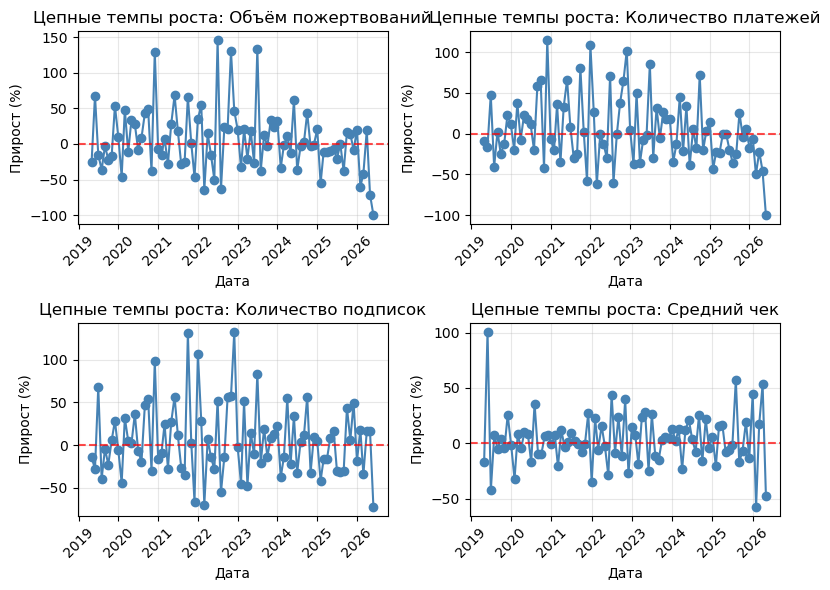

In [58]:
# Визуализиация цепных иемпов роста
fig, axes = plt.subplots(2, 2, figsize=(8, 6))
titles = ['Объём пожертвований', 'Количество платежей', 'Количество подписок', 'Средний чек']

for ax, col, title in zip(axes.flat, metrics, titles):
    ax.plot(monthly['Год_месяц'], monthly[f'{col}_growth'], marker='o', linewidth=1.5, color='steelblue')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'Цепные темпы роста: {title}', fontsize=12)
    ax.set_xlabel('Дата')
    ax.set_ylabel('Прирост (%)')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

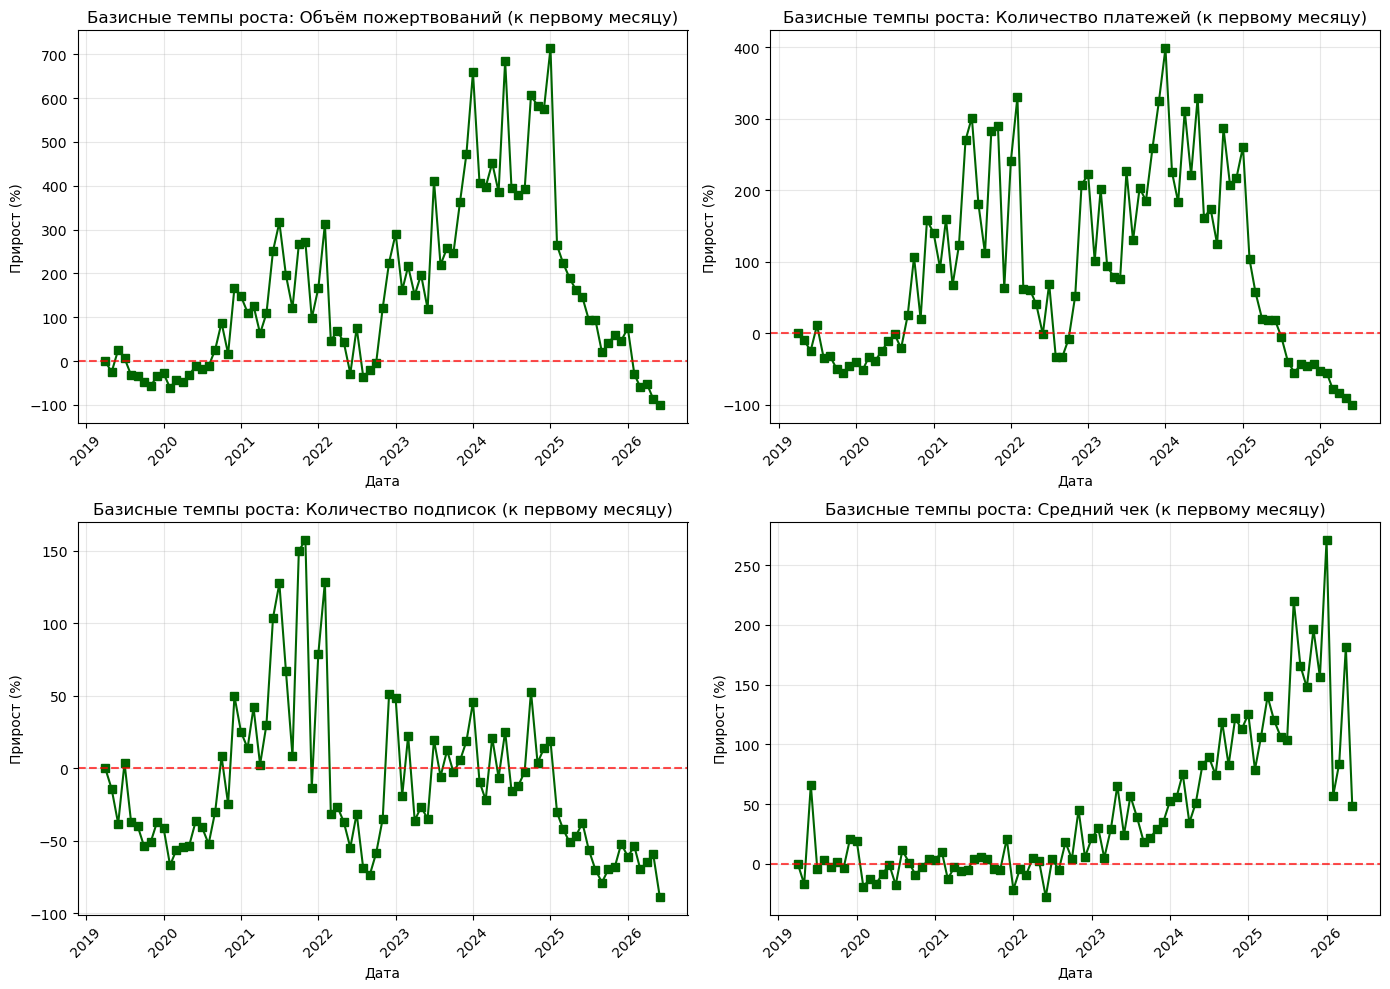

In [59]:
# Визуализиция базисных показателей
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, col, title in zip(axes.flat, metrics, titles):
    ax.plot(monthly['Год_месяц'], monthly[f'{col}_cum'], marker='s', linewidth=1.5, color='darkgreen')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.7)
    ax.set_title(f'Базисные темпы роста: {title} (к первому месяцу)', fontsize=12)
    ax.set_xlabel('Дата')
    ax.set_ylabel('Прирост (%)')
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

**Анализ цепных темпов роста:**
    
Средний чек часто рос, даже когда объём падал (август, ноябрь, январь, апрель). Т.е. крупные донаторы ещё оставались, но их становилось меньше.

Количество подписок в некоторые месяцы росло (декабрь, февраль, апрель, май), но это не приводило к росту платежей – значит, люди оформляли подписки, но не оплачивали их.

Обвал в феврале и мае – самые глубокие падения, после которых восстановление было незначительным.

**Анализ базисных темпов роста:**

Объём и платежи – до января 2026 базисный рост был положительным (до + 94% и + 76% соответственно). С февраля они уходят в минус и к июню падают до –100%. Это означает, что фонд потерял все накопленные за 7 лет достижения.

Подписки – базисный рост был отрицательным весь период (от –52% до –89%). Это говорит о том, что количество новых подписок никогда не достигало уровня 2019 года. Проблема с привлечением существовала давно.

Средний чек – базисный рост оставался высоким (до +271% в январе 2026), но затем резко упал. Это подтверждает, что крупные донаторы уходят, и фонд теряет основной источник доходов.

### Промежуточный вывод

Таким образом, мы видим по показателям:

2019–2023: устойчивый рост, выход на плато в 2024 году.

2025: начало спада, сезонные пики сглаживаются.

2026: катастрофическое падение – к июню объём и платежи обнулились.

# 3.3. Проведем RFM-анализ.

- **R (давность)** — дней с последнего платежа. Пороги заданы от логики ежемесячных списаний: до 60 дней — платёж мог пройти в последние два цикла, донатор активен; 61–180 — списания недавно прекратились, зона риска; более 180 — донатор ушёл. 
- **F (частота)** — всего платежей: 1 — попробовал; 2–6 — платил до полугода; 7 и более — постоянный донатор.
- **M (деньги)** — суммарный сбор с донатора, три равные группы (терцили).

In [60]:
CUTOFF = pd.Timestamp("2026-06-18 23:59:59")  # дата выгрузки | дата среза

In [61]:
# Определяем, какие подписки живы на дату среза
alive = df["статус"].isin(["активна", "просрочена", "в_ожидании"])

# Создаем колонку-флаг
df["жива_на_срезе"] = alive

In [62]:
df["сбор"] = df["сумма"] * df["кол-во_платежей"]

donors = df.groupby("id_плательщика").agg(
    подписок=("id", "count"),
    платежей=("кол-во_платежей", "sum"),
    сбор=("сбор", "sum"),
    последний_платёж=("дата/время_последнего_платежа", "max"),
    первая_подписка=("дата/время_создания", "min"),
    жив=("жива_на_срезе", "max")
)
len(donors)

31105

In [63]:
# Оставляем только тех, кто совершил хотя бы один платёж
rfm_data = donors[donors['платежей'] > 0]

In [64]:
payers = rfm_data[rfm_data["платежей"] > 0].copy()
print("платившие:", len(payers), "| не платившие:", (rfm_data["платежей"] == 0).sum())

payers["R_дней"] = (CUTOFF - payers["последний_платёж"]).dt.days
payers["R"] = pd.cut(payers["R_дней"], bins=[-1, 60, 180, 10**9],
                     labels=["активный (≤60)", "риск (61-180)", "ушедший (>180)"])

payers["F"] = pd.cut(payers["платежей"], bins=[0, 1, 6, 10**9],
                     labels=["разовый (1)", "пробующий (2-6)", "постоянный (7+)"])

payers["M"] = pd.qcut(payers["сбор"], 3, labels=["низкий", "средний", "высокий"])

payers[["R", "F", "M"]].apply(lambda col: col.value_counts())

платившие: 21864 | не платившие: 0


,R,F,M
активный (≤60),4536.0,NaN,NaN
высокий,NaN,NaN,7208.0
низкий,NaN,NaN,8136.0
постоянный (7+),NaN,9057.0,NaN
пробующий (2-6),NaN,7422.0,NaN
разовый (1),NaN,5385.0,NaN
риск (61-180),872.0,NaN,NaN
средний,NaN,NaN,6520.0
ушедший (>180),16456.0,NaN,NaN


R (Давность):

Активные (≤60 дней): 4536 (20.7%) - это ядро, Риск (61-180 дней):  872 (4.0%) - нужно спасать, Ушедшие (>180 дней):  16,456 (75.3%) - большой потенциал возврата.

F (Частота) - определяет ценность:

Разовые (1)- 5,385 (24.6%)
Пробующие (2-6)- 7,422 (34.0%)
Постоянные (7+) - 9,057 (41.4%) 
Постоянные донаторы - это 41% людей, но 86% денег.

Ценность донатора определяется частотой (F), а не суммой (M). Постоянные донаторы (7+ платежей) - это 41.4 % людей, но 86% всех сборов.

In [65]:
rfm = payers.groupby(["R", "F"], observed=True).agg(
    донаторов=("сбор", "size"),
    сбор_всего=("сбор", "sum"),
    средний_сбор=("сбор", "mean"),
)
rfm["доля_людей_%"] = (rfm["донаторов"] / len(payers) * 100).round(1)
rfm["доля_денег_%"] = (rfm["сбор_всего"] / payers["сбор"].sum() * 100).round(1)
rfm.round(0)

донаторов  сбор_всего  средний_сбор  \
R              F                                                      
активный (≤60) разовый (1)            120     82625.0         689.0   
               пробующий (2-6)        591   1492258.0        2525.0   
               постоянный (7+)       3825  38441175.0       10050.0   
риск (61-180)  разовый (1)             91     45081.0         495.0   
               пробующий (2-6)        196    504572.0        2574.0   
               постоянный (7+)        585   4222700.0        7218.0   
ушедший (>180) разовый (1)           5174   1740954.0         336.0   
               пробующий (2-6)       6635   6902020.0        1040.0   
               постоянный (7+)       4647  20697869.0        4454.0   

                                доля_людей_%  доля_денег_%  
R              F                                            
активный (≤60) разовый (1)               0.0           0.0  
               пробующий (2-6)           3.0           2.0  
               постоянный (7+)          18.0          52.0  
риск (61-180)  разовый (1)               0.0           0.0  
               пробующий (2-6)           1.0           1.0  
               постоянный (7+)           3.0           6.0  
ушедший (>180) разовый (1)              24.0           2.0  
               пробующий (2-6)          30.0           9.0  
               постоянный (7+)          21.0          28.0

| Сегмент | R и F | Кол-во (%) людей | Доля денег | Рекомендации |
|:--|:--|--:|--:|:--|
| Ядро | активный × 7+ | 3 825 (18%) | 52% | Отправлять годовые отчеты об использовании средств, персональные письма с благодарность, обеспечить бесперебойной списание средств за подписку. Необходимо удержание этих донатеров. |
| Растущие | активный × 2–6 | 711 (3%) | 2% | рассказывать историю подоопечного, которому помогает, для большего вовлечения. Необходимо конвентировать в постоянного донатора. |
| Под угрозой | риск × 7+ | 585 (3%) | 6% | Сделать уведомления о сбое списания автоматическими. Необходимо "спасти" каждого донатора из сегмента. |
| Спящие постоянные | ушедший × 7+ | 4 647 (21%) | 28% | Напомнить о добрых делах, которые они уже сделали,показать текущие проекты, которые нуждаются в помощи. Вернуть хотя бы 10 % сегмента.|
| Ушедшие разовые и пробующие | ушедший × 2–6 | 11 809 (54%) | 11% |Призыв вернуться с любой суммой, возможность разового пожертвования. |
| Не запустившиеся | вне сетки | 9 240 | 0% | Письмо с предложением повторить оплату другой картой, предложить альтернативные способы оплаты.  |

# 3.4. Проведем когортный анализ по месяцу первого пожертвования.

In [66]:
df['дата/время_создания'] = pd.to_datetime(
    df['дата/время_создания'], 
    dayfirst=True)

In [67]:
# Функция, которая преобразует любую дату в первый день месяца
# Это нужно для группировки транзакций по месяцам (когортам)
def get_month(x): 
    return dt.datetime(x.year, x.month, 1)

# Применяем функцию к каждой дате транзакции
# Теперь все транзакции за один месяц имеют одинаковую дату (первое число)
df['TransactionMonth'] = df['дата/время_создания'].apply(get_month)

grouping = df.groupby('id_плательщика')['TransactionMonth']

# ОПРЕДЕЛЕНИЕ МЕСЯЦА ПЕРВОЙ ТРАНЗАКЦИИ (КОГОРТЫ)
# Для каждого клиента находим минимальный (самый ранний) месяц транзакции
# Это и будет месяц его "рождения" как клиента — его когорта
df['CohortMonth'] = grouping.transform('min')

print(df.head())

                                 id дата/время_создания   статус   сумма  \
0  sc_5fd0defafe7ff468dbd3257da445c 2026-06-18 08:39:25  активна  1000.0   
1  sc_fb4115049bb199106b401cb66c8bb 2026-06-17 20:57:39  активна   100.0   
2  sc_1dad551bda204a1c1ce3a60573458 2026-06-17 20:35:25  активна   100.0   
3  sc_9c512c6a7880f7cceb309c654c7ef 2026-06-16 20:37:05  активна   500.0   
4  sc_b1911b7fb5bd247c6c40f25707aed 2026-06-16 15:43:23  активна   100.0   

  валюта периодичность                                           описание  \
0      ₽   Раз в месяц  благотворительное_пожертвование._ежемесячная_п...   
1      ₽   Раз в месяц                    благотворительное_пожертвование   
2      ₽   Раз в месяц                    благотворительное_пожертвование   
3      ₽   Раз в месяц  благотворительное_пожертвование._ежемесячная_п...   
4      ₽   Раз в месяц  благотворительное_пожертвование._ежемесячная_п...   

     id_плательщика  кол-во_платежей дата/время_последнего_платежа  ... месяц  \

In [68]:
def get_date_int(df, column):
    year = df[column].dt.year
    month = df[column].dt.month
    day = df[column].dt.day
    return year, month, day

# Извлекаем числовые значения частей даты (год, месяц, день) из колонки `TransactionMonth`
transcation_year, transaction_month, _ = get_date_int(df, 'TransactionMonth')

# Извлекаем числовые значения частей даты (год, месяц, день) из колонки `CohortMonth`
cohort_year, cohort_month, _ = get_date_int(df, 'CohortMonth')

In [69]:
# Вычисляем разницу в годах между текущей транзакцией и первой транзакцией донатора
years_diff = transcation_year - cohort_year

# Вычисляем разницу в месяцах между текущей транзакцией и первой транзакцией донатора
months_diff = transaction_month - cohort_month

""" Переводим разницу в годах и месяцах в общее количество месяцев.
"+1" добавляется в конце, чтобы первый месяц обозначался как 1, 
а не как 0 — так удобнее для интерпретации """

df['CohortIndex'] = years_diff * 12 + months_diff  + 1 
print(df.head(5))

                                 id дата/время_создания   статус   сумма  \
0  sc_5fd0defafe7ff468dbd3257da445c 2026-06-18 08:39:25  активна  1000.0   
1  sc_fb4115049bb199106b401cb66c8bb 2026-06-17 20:57:39  активна   100.0   
2  sc_1dad551bda204a1c1ce3a60573458 2026-06-17 20:35:25  активна   100.0   
3  sc_9c512c6a7880f7cceb309c654c7ef 2026-06-16 20:37:05  активна   500.0   
4  sc_b1911b7fb5bd247c6c40f25707aed 2026-06-16 15:43:23  активна   100.0   

  валюта периодичность                                           описание  \
0      ₽   Раз в месяц  благотворительное_пожертвование._ежемесячная_п...   
1      ₽   Раз в месяц                    благотворительное_пожертвование   
2      ₽   Раз в месяц                    благотворительное_пожертвование   
3      ₽   Раз в месяц  благотворительное_пожертвование._ежемесячная_п...   
4      ₽   Раз в месяц  благотворительное_пожертвование._ежемесячная_п...   

     id_плательщика  кол-во_платежей дата/время_последнего_платежа  ...  \
0  PI

In [70]:
# Группируем данные по месяцу когорты (CohortMonth) и месяцу жизни донатора (CohortIndex)
# Это позволяет посчитать, сколько донаторов из каждой когорты остались активны
# в каждый месяц своей "жизни"
grouping = df.groupby(['CohortMonth', 'CohortIndex'])


# Для каждой группы (когорта + месяц жизни) считаем количество уникальных донаторов
cohort_data = grouping['id_плательщика'].apply(pd.Series.nunique)
cohort_data = cohort_data.reset_index()


# СОЗДАНИЕ СВОДНОЙ ТАБЛИЦЫ (PIVOT TABLE)

cohort_counts = cohort_data.pivot(index='CohortMonth',
                                 columns ='CohortIndex',
                                 values = 'id_плательщика')
cohort_data.head()

,CohortMonth,CohortIndex,id_плательщика
0,2019-04-01,1,510
1,2019-04-01,2,35
2,2019-04-01,3,4
3,2019-04-01,4,10
4,2019-04-01,5,6


In [71]:
"""
Выбираем первый столбец (CohortIndex = 1) и сохраняем его как размер когорты.
Это количество активных донаторов в первый месяц их жизни.

"""

cohort_sizes = cohort_counts.iloc[:,0]

"""
Делим все значения в таблице на размер соответствующей когорты.
Это позволяет рассчитать процент удержания — долю донаторов,
которые остались активны в каждый месяц жизни.

Формула:
Retention = (Количество активных донаторов в месяце N) / (Размер когорты)
"""

retention = cohort_counts.divide(cohort_sizes, axis=0)

In [72]:
# Переводим коэффициент удержания в проценты и округляем
retention.round(3)*100

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,66,68,69,70,71,72,73,77,80,84
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2019-04-01,100.0,6.9,0.8,2.0,1.2,0.8,0.8,0.2,0.4,0.4,...,0.2,NaN,NaN,NaN,NaN,NaN,0.2,NaN,NaN,0.2
2019-05-01,100.0,1.7,1.9,0.7,1.0,0.7,0.5,0.2,0.7,0.2,...,0.5,NaN,0.2,NaN,0.2,NaN,NaN,0.2,NaN,NaN
2019-06-01,100.0,3.5,1.9,1.6,1.0,1.3,0.3,0.3,0.3,0.3,...,0.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-07-01,100.0,3.1,1.6,0.8,0.4,0.6,0.8,0.4,0.4,0.4,...,NaN,0.2,0.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08-01,100.0,1.7,1.4,1.0,0.7,0.7,0.7,1.4,0.7,1.0,...,NaN,NaN,NaN,0.3,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-01,100.0,1.8,2.4,1.8,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-01,100.0,NaN,1.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-04-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


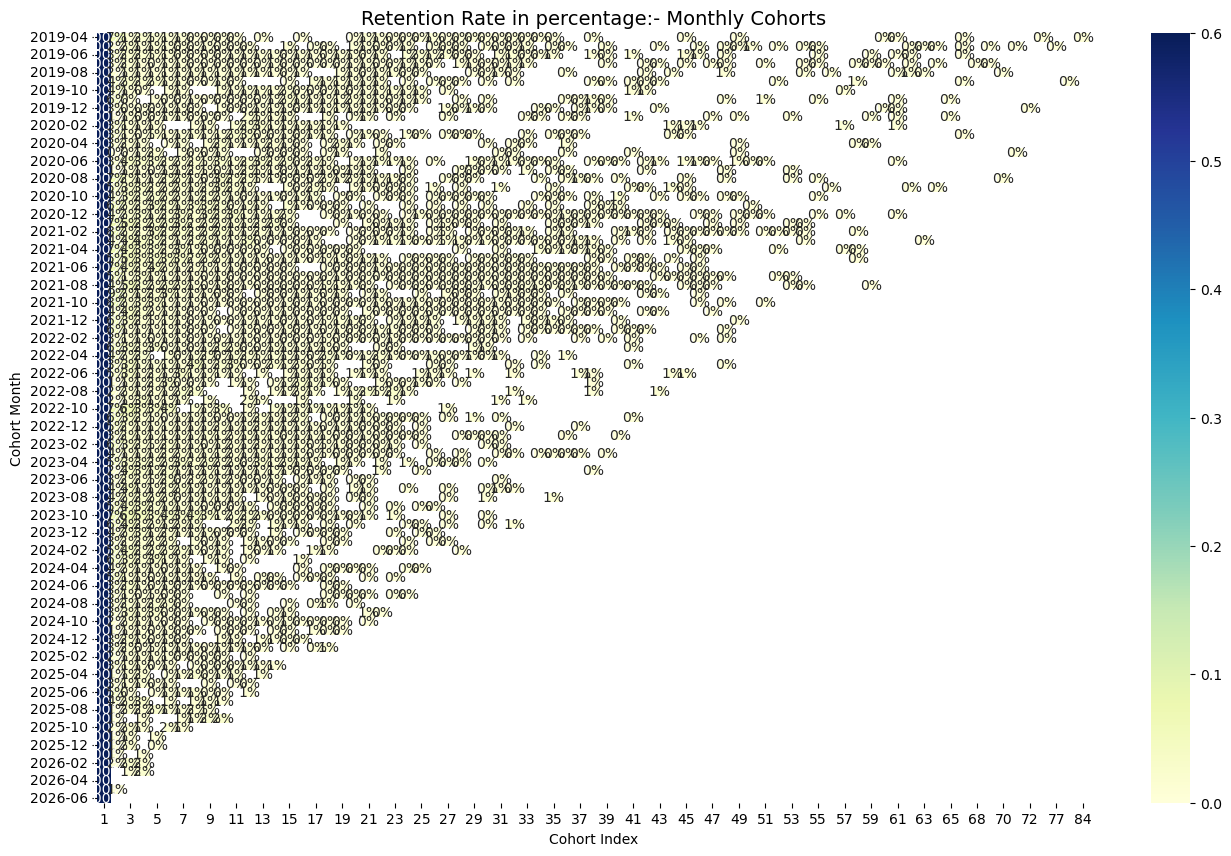

In [73]:
retention.index = pd.to_datetime(retention.index)

retention.index = retention.index.strftime('%Y-%m')
plt.figure(figsize=(16, 10))
plt.title('Retention Rate in percentage:- Monthly Cohorts', fontsize = 14)
sns.heatmap(retention, annot=True, fmt= '.0%',cmap='YlGnBu', vmin = 0.0 , vmax = 0.6)
plt.ylabel('Cohort Month')
plt.xlabel('Cohort Index')
plt.show()

In [74]:
# Среднее удержание по месяцам жизни
avg_retention = retention.mean(axis=0)
print("\n  Среднее удержание по месяцам жизни:")
for idx, val in avg_retention.items():
    print(f"  {idx}-й месяц: {val:.1%}")

# Самый критичный месяц (наибольшее падение)
if len(avg_retention) > 1:
    drops = []
    for i in range(1, len(avg_retention)):
        prev = avg_retention.iloc[i-1]
        curr = avg_retention.iloc[i]
        drop = (prev - curr) / prev * 100 if prev > 0 else 0
        drops.append((i+1, drop))
    
    max_drop = max(drops, key=lambda x: x[1])
    print(f"\n  Самый критичный переход: с {max_drop[0]-1}-го на {max_drop[0]}-й месяц")
    print(f"   Потеря: {max_drop[1]:.1f}% от оставшихся")

# Лучшая и худшая когорта
avg_cohorts = retention.mean(axis=1)
best_cohort = avg_cohorts.idxmax()
worst_cohort = avg_cohorts.idxmin()
print(f"\n  Лучшая когорта: {best_cohort} (среднее удержание {avg_cohorts.max():.1%})")
print(f"  Худшая когорта: {worst_cohort} (среднее удержание {avg_cohorts.min():.1%})")

# Тренд по когортам
if len(retention) >= 3:
    recent = retention.iloc[-3:].mean(axis=1).mean()
    older = retention.iloc[:3].mean(axis=1).mean()
    trend = "  Улучшается" if recent > older else "📉 Ухудшается"
    print(f"\n  Тренд удержания: {trend}")
    print(f"   Среднее за последние 3 когорты: {recent:.1%}")
    print(f"   Среднее за первые 3 когорты: {older:.1%}")
else:
    print("\n  Недостаточно когорт для анализа тренда")


  Среднее удержание по месяцам жизни:
  1-й месяц: 100.0%
  2-й месяц: 3.9%
  3-й месяц: 2.2%
  4-й месяц: 1.6%
  5-й месяц: 1.5%
  6-й месяц: 1.3%
  7-й месяц: 1.2%
  8-й месяц: 1.1%
  9-й месяц: 0.9%
  10-й месяц: 1.0%
  11-й месяц: 0.9%
  12-й месяц: 0.9%
  13-й месяц: 0.9%
  14-й месяц: 0.8%
  15-й месяц: 0.7%
  16-й месяц: 0.7%
  17-й месяц: 0.6%
  18-й месяц: 0.6%
  19-й месяц: 0.6%
  20-й месяц: 0.6%
  21-й месяц: 0.6%
  22-й месяц: 0.6%
  23-й месяц: 0.5%
  24-й месяц: 0.5%
  25-й месяц: 0.5%
  26-й месяц: 0.4%
  27-й месяц: 0.4%
  28-й месяц: 0.3%
  29-й месяц: 0.4%
  30-й месяц: 0.4%
  31-й месяц: 0.4%
  32-й месяц: 0.5%
  33-й месяц: 0.4%
  34-й месяц: 0.3%
  35-й месяц: 0.4%
  36-й месяц: 0.4%
  37-й месяц: 0.3%
  38-й месяц: 0.4%
  39-й месяц: 0.3%
  40-й месяц: 0.3%
  41-й месяц: 0.4%
  42-й месяц: 0.3%
  43-й месяц: 0.3%
  44-й месяц: 0.4%
  45-й месяц: 0.4%
  46-й месяц: 0.3%
  47-й месяц: 0.2%
  48-й месяц: 0.3%
  49-й месяц: 0.4%
  50-й месяц: 0.4%
  51-й месяц: 0.3%

Кризис на 2-м месяце: 96.1 % донаторов уходят после первого месяца. Позитивный тренд: новые когорты удерживаются в 28 раз лучше старых (83.5% и 3.0%). Анализ показывает критическую точку оттока — переход между первым и вторым месяцем. Из 100 донаторов, которые сделали первый платеж, 96 человек не возвращаются для второго. Это означает, что почти все донаторы воспринимают своё участие как разовую акцию, а не как долгосрочные отношения с организацией. После второго месяца ситуация только ухудшается. К третьему месяцу остаётся всего 2% от первоначального числа донаторов, а к концу года — меньше 1%. Это значит, что долгосрочные отношения с донаторами не выстраиваются.
Несмотря на общую тревожную картину, есть очень обнадёживающий тренд. Если посмотреть на самые старые когорты донаторов (2019 год), их удержание составляло всего 3%. А самые новые когорты (2026 год) показывают удержание уже 83%.

Это означает, что изменения, которые организация внедрила за последние годы, работают. Новые донаторы приходят более осознанными, лучше понимают ценность проекта, и их возвращаемость выросла в 28 раз по сравнению с первыми годами. Это колоссальный прогресс, который говорит о правильном направлении развития.

Рекомендации:

Усилить онбординг в первую неделю. Сразу после доната отправить персонализированное письмо с благодарностью и рассказом, как именно его помощь будет использована. Показать, что он уже часть сообщества.

Показать быстрый результат. В течение первых 7-10 дней отправить отчёт о первых изменениях, которые произошли благодаря его вкладу. 

Создать «эффект привычки». Настроить автоматическую серию писем на 7, 14, 21 и 28 день. Каждое письмо должно давать новую порцию вдохновения и показывать прогресс.

Предложить удобный способ оставаться в курсе. Подписать на рассылку, пригласить в закрытый Telegram-канал или группу в соцсетях, где публикуются эксклюзивные новости.

## 3.5. Исследуем подписки.

In [75]:
df.head()

,id,дата/время_создания,статус,сумма,валюта,периодичность,описание,id_плательщика,кол-во_платежей,дата/время_последнего_платежа,...,Объем_пожертвований,Год_месяц,real_revenue,Месяц,Год,жива_на_срезе,сбор,TransactionMonth,CohortMonth,CohortIndex
0,sc_5fd0defafe7ff468dbd3257da445c,2026-06-18 08:39:25,активна,1000.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_41ef2e0fdbe2,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2026-06-01,1
1,sc_fb4115049bb199106b401cb66c8bb,2026-06-17 20:57:39,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование,PID_34f44fc59dc0,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2026-06-01,1
2,sc_1dad551bda204a1c1ce3a60573458,2026-06-17 20:35:25,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование,PID_1070551ebf1b,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2026-06-01,1
3,sc_9c512c6a7880f7cceb309c654c7ef,2026-06-16 20:37:05,активна,500.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_cd9879f83789,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2026-06-01,1
4,sc_b1911b7fb5bd247c6c40f25707aed,2026-06-16 15:43:23,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_6bf236df9e02,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2025-01-01,18


In [76]:
# Долю регулярных подписок

In [77]:
# общая сумма пожертвований
df['real_revenue'] = df['сумма'] * df['кол-во_платежей']
total_revenue = df['real_revenue'].sum()

In [78]:
# регулярные подписки
regular_df = df[df['периодичность'] == 'Раз в месяц']
regular_revenue = regular_df['real_revenue'].sum()
regular_df.head(5)

,id,дата/время_создания,статус,сумма,валюта,периодичность,описание,id_плательщика,кол-во_платежей,дата/время_последнего_платежа,...,Объем_пожертвований,Год_месяц,real_revenue,Месяц,Год,жива_на_срезе,сбор,TransactionMonth,CohortMonth,CohortIndex
0,sc_5fd0defafe7ff468dbd3257da445c,2026-06-18 08:39:25,активна,1000.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_41ef2e0fdbe2,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2026-06-01,1
1,sc_fb4115049bb199106b401cb66c8bb,2026-06-17 20:57:39,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование,PID_34f44fc59dc0,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2026-06-01,1
2,sc_1dad551bda204a1c1ce3a60573458,2026-06-17 20:35:25,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование,PID_1070551ebf1b,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2026-06-01,1
3,sc_9c512c6a7880f7cceb309c654c7ef,2026-06-16 20:37:05,активна,500.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_cd9879f83789,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2026-06-01,1
4,sc_b1911b7fb5bd247c6c40f25707aed,2026-06-16 15:43:23,активна,100.0,₽,Раз в месяц,благотворительное_пожертвование._ежемесячная_п...,PID_6bf236df9e02,0,NaT,...,0.0,2026-06,0.0,6,2026,True,0.0,2026-06-01,2025-01-01,18


In [79]:
share_of_regular_revenue = (regular_revenue / total_revenue) * 100
print(f"Доля регулярных пожертвований в общем объёме: {share_of_regular_revenue:.2f}%")

Доля регулярных пожертвований в общем объёме: 100.00%


In [80]:
# средняя сумма регулярного платежа 
avg_regular_payment = regular_df['сумма'].mean()
print(f"Средняя сумма регулярного платежа: {avg_regular_payment:.2f}")

Средняя сумма регулярного платежа: 338.59


In [81]:
# количество активных подписок
active_regular = regular_df[regular_df['статус'] == 'активна'].shape[0]
print(f"Количество активных подписок: {active_regular:.2f}")

Количество активных подписок: 4827.00


In [82]:
# Рассмотрим среднюю длительность подписки

In [83]:
# Фильтруем 
completed = df[df['статус'] != 'активна'].copy()

# Вычисляем длительность в днях
completed['duration_days'] = (completed['дата/время_последнего_платежа'] - completed['дата/время_создания']).dt.days
completed['duration_months'] = completed['duration_days'] / 30

In [84]:
# Исключаем подписки, где последний платёж отсутствует (если такие есть)
completed = completed.dropna(subset=['duration_days'])

# Средняя длительность в днях, месяцах 
avg_duration_days = completed['duration_days'].mean()
avg_duration_months = avg_duration_days / 30
avg_duration_years = avg_duration_days / 365
print(f"Средняя длительность завершённых подписок: {avg_duration_days:.1f} дней ({avg_duration_months:.1f} месяцев)")


Средняя длительность завершённых подписок: 199.2 дней (6.6 месяцев)


In [85]:
# Исследуем распределение срока жизни подписки

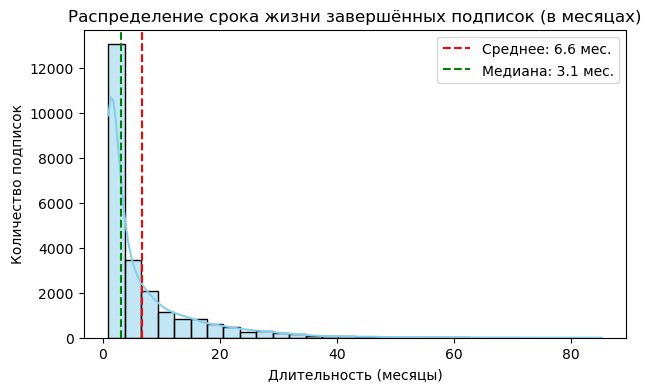

In [86]:
plt.figure(figsize=(7, 4))
sns.histplot(completed['duration_months'], bins=30, kde=True, color='skyblue')
plt.title('Распределение срока жизни завершённых подписок (в месяцах)')
plt.xlabel('Длительность (месяцы)')
plt.ylabel('Количество подписок')
plt.axvline(completed['duration_months'].mean(), color='red', linestyle='--', label=f'Среднее: {completed["duration_months"].mean():.1f} мес.')
plt.axvline(completed['duration_months'].median(), color='green', linestyle='--', label=f'Медиана: {completed["duration_months"].median():.1f} мес.')
plt.legend()
plt.show()

In [87]:
completed['duration_months'].describe()

count    23840.000000
mean         6.639595
std          8.487474
min          0.933333
25%          1.033333
50%          3.066667
75%          8.166667
max         85.200000
Name: duration_months, dtype: float64

В среднем длительность подписки составляет 6.6 месяца, медиана составляет примерно 3 месяца (типичный срок), т.е. половина всех подписок живет меньше 3х месяцев, что весьма мало. 25 % подписок заканчиваются в первый месяц (четверь донаторов уходит после первого или второго платежа). 75 % подписок живут менее 8 месяцев, т.е. только 25 % доживают до 8 месяцев и более.

In [88]:
# Изучим уровень оттока

In [89]:
# Все подписки с хотя бы одним платежом
active_subscriptions = df[df['кол-во_платежей'] > 0]
total = len(active_subscriptions)

# Завершённые (не активные)
churned = len(active_subscriptions[active_subscriptions['статус'] != 'активна'])

churn_rate_overall = churned / total * 100
print(f"Общий уровень оттока: {churn_rate_overall:.1f}%")
print(f"Активных подписок: {total - churned}")
print(f"Завершённых подписок: {churned}")

Общий уровень оттока: 83.5%
Активных подписок: 4697
Завершённых подписок: 23840


Общий уровень оттока в 84 % является огромным, означает, что из 10 донаторов, оформивших подписку, только 2 остаются активными. Это может происходить из-за высокого оттока на начальном этапе платежа, а так же  оказывать влияние сезонные факторы.

In [90]:
# Средний уровень платежей на подписчика 

In [91]:
df_active = df[df['кол-во_платежей'] > 0].copy()
avg_payments_per_subscription = df_active['кол-во_платежей'].mean()
median_payments_per_subscription = df_active['кол-во_платежей'].median()
min_payments = df_active['кол-во_платежей'].min()
max_payments = df_active['кол-во_платежей'].max()

print(f"Среднее количество платежей на подписку: {avg_payments_per_subscription:.2f}")
print(f"Медианное количество платежей на подписку: {median_payments_per_subscription:.2f}")
print(f"Минимум: {min_payments}, Максимум: {max_payments}")

Среднее количество платежей на подписку: 8.35
Медианное количество платежей на подписку: 4.00
Минимум: 1, Максимум: 85


In [92]:
donor_payments = df_active.groupby('id_плательщика')['кол-во_платежей'].sum().reset_index()
donor_payments.columns = ['id_плательщика', 'total_payments']

avg_payments_per_donor = donor_payments['total_payments'].mean()
median_payments_per_donor = donor_payments['total_payments'].median()
min_payments_donor = donor_payments['total_payments'].min()
max_payments_donor = donor_payments['total_payments'].max()

print(f"Среднее количество платежей на донатора: {avg_payments_per_donor:.2f}")
print(f"Медианное количество платежей на донатора: {median_payments_per_donor:.2f}")
print(f"Минимум: {min_payments_donor}, Максимум: {max_payments_donor}")

Среднее количество платежей на донатора: 10.90
Медианное количество платежей на донатора: 4.00
Минимум: 1, Максимум: 1863


Выводы:
Медиана (4 платежа) – ключевой показатель. Половина всех подписок и донаторов имеют ≤ 4 платежей.
Это значит, что типичный донатор платит всего 4 раза (примерно 4 месяца, если ежемесячная подписка). Это подтверждает ранние выводы о коротком жизненном цикле.

Среднее значительно выше медианы.
На подписку: среднее 8.35 > медиана 4.0 → разрыв в 2 раза.
На донатора: среднее 10.9 > медиана 4.0 → разрыв почти в 3 раза.
Это говорит о сильной скошенности распределения – есть небольшое число "супер-донаторов" (хвост), которые делают десятки и сотни платежей, и они сильно "тянут" среднее вверх. 

У донаторов среднее (10.9) выше, чем у подписок (8.35). Это логично, потому что один донатор может иметь несколько подписок, и суммарное число платежей у него больше.Однако медиана у них одинаковая – 4. Это говорит о том, что даже с учётом нескольких подписок, большинство донаторов всё равно делают не более 4 платежей в сумме.

Основная масса донаторов (50%+) "отваливается" после 4-го платежа.
Это точка, где нужно прилагать максимум усилий для удержания.

Рекомендации:
Сфокусироваться на удержании донаторов до 5-го платежа.
Если донатор доходит до 5 платежей, он с высокой вероятностью продолжит. Нужно понять, что происходит на 4-м платеже и почему многие уходят именно после него.

Сегментировать донаторов по количеству платежей:

**1 платёж** – новые, нуждаются в онбординге.

**2–4 платежа** – "рискующие", нуждаются в дополнительной мотивации.

**5+ платежей** – "лояльные", их нужно поощрять и благодарить.

**10+ платежей** – "супер-донаторы", им нужен особый подход (эксклюзивные отчёты, личные письма).

### Промежуточный вывод

Исходя из данных выше, мы наблюдаем, что жизненый цикл подписки очень короткий, это значит, что необходимо удержание донатора с ранних дней. Главная задача на ближайший период: снизить отток в первые 3 месяца и увеличить долю донаторов, доходящих до 5-го платежа. Это даст наибольший рост LTV и финансовой устойчивости фонда.

## 3.6. Проведем Survival Analysis (анализ выживаемости подписок).

In [93]:
# Постром кривую Каплана—Майера (Kaplan–Meier)

Кривая Каплана - Майера  -  золотой стандарт для анализа выживаемости в подписочных моделях. Это визуализация функции выживаемости, которая показывает, какая доля объектов (подписок) остаётся «живой» (активной) с течением времени.  

Она корректно учитывает цензурированные данные (учитывает активные подписки), устойчива к выбросам, позволяет сравнивать группы, выявляет критические периоды.

In [94]:
CUTOFF = pd.Timestamp("2026-06-18 23:59:59")  # дата выгрузки

alive = df["статус"].isin(["активна", "просрочена", "в ожидании"])

# правило заказчика: конец жизни = дата последнего платежа,
# а если платежей не было вообще — дата создания (жизнь нулевой длины)
df["конец_жизни"] = df["дата/время_последнего_платежа"].fillna(df["дата/время_создания"])

# живые подписки ещё не кончились: их "конец" - это дата среза данных
df.loc[alive, "конец_жизни"] = CUTOFF
df["жива_на_срезе"] = alive

In [95]:
# Длительность жизни подписки
df["дней_жизни"] = (df["конец_жизни"] - df["дата/время_создания"]).dt.days
df["месяцев_жизни"] = df["дней_жизни"] / 30.44

30     0.607238
91     0.398656
183    0.293506
365    0.210837
Name: KM_estimate, dtype: float64
медианное время жизни, дней: 33.0


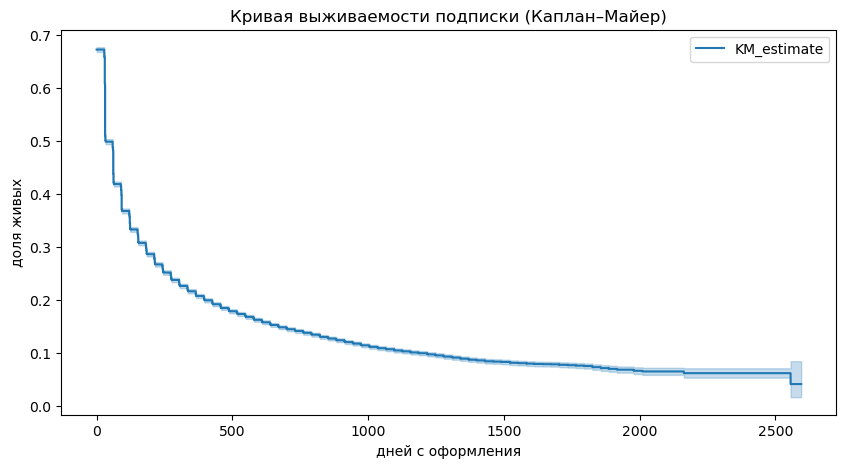

In [96]:
#  флаг события: подписка умерла 
df["event"] = ~df["жива_на_срезе"]

kmf = KaplanMeierFitter()
kmf.fit(df["дней_жизни"], event_observed=df["event"])

ax = kmf.plot_survival_function(figsize=(10, 5))
ax.set_xlabel("дней с оформления"); ax.set_ylabel("доля живых")
ax.set_title("Кривая выживаемости подписки (Каплан–Майер)")

#  контрольные точки ТЗ: 1,3,6,12 месяцев + медиана
print(kmf.predict([30, 91, 183, 365]))
print("медианное время жизни, дней:", kmf.median_survival_time_)

Очень быстрое отпадение подписчиков в первый месяц. Медианное время жизни подписки составляет всего 33 дня. Это значит, что 50% подписчиков «умирают» (отписываются) уже через 33 дня после оформления подписки.
На графике видно, что уже в первые 30 дней доля «живых» подписчиков падает ниже 0,5 (чуть больше 40%). Это подтверждает, что основной отток происходит в первый месяц.
По прогнозам:

- Через 3 месяца (91 день) — выживаемость  0,2–0,3 (примерно 20–30%).

- Через 6 месяцев (183 дня) — выживаемость падает до 0,1–0,15.

- Через 12 месяцев (365 дней) — остаётся менее 10% подписчиков.

Рекомендации по улучшению:
- Усилить работу с новыми подписчиками в первые 7–14 дней.

- Внедрить триггеры вовлечения (пуш-уведомления, персонализация, бонусы).

- Проанализировать, почему пользователи уходят именно на 30-й день (возможно, заканчивается пробный период или первый платёж).  

Подписка имеет краткосрочную модель удержания — большинство пользователей уходит в течение первого месяца, и без серьёзных изменений в продукте или коммуникации долгосрочное удержание маловероятно.

In [97]:
# Определим наиболее критичные периоды ухода донаторов

In [98]:
# КОНТРОЛЬНЫЕ ТОЧКИ 
print("КОНТРОЛЬНЫЕ ТОЧКИ ВЫЖИВАЕМОСТИ")


time_points = [30, 91, 183, 365]
survival_probs = []

for t in time_points:
    result = kmf.predict(t)
    if np.isscalar(result):
        survival_probs.append(result)
    else:
        survival_probs.append(result[0])

survival_probs = np.array(survival_probs)

print(f"{'Период':15} {'Выжило':>10} {'Умерло':>10}")

for t, s in zip(time_points, survival_probs):
    print(f"{t:3} дней (~{t//30:1} мес): {s:>9.1%} {1-s:>9.1%}")

print(f"\nМедианное время жизни: {kmf.median_survival_time_:.0f} дней")

КОНТРОЛЬНЫЕ ТОЧКИ ВЫЖИВАЕМОСТИ
Период              Выжило     Умерло
 30 дней (~1 мес):     60.7%     39.3%
 91 дней (~3 мес):     39.9%     60.1%
183 дней (~6 мес):     29.4%     70.6%
365 дней (~12 мес):     21.1%     78.9%

Медианное время жизни: 33 дней


In [99]:
#  ПОИСК ПИКОВ ОТТОКА (через таблицу выживаемости)
print("ПИКИ ОТТОКА (Hazard Rate)")
# Берём таблицу выживаемости из KM-модели
survival_table = kmf.survival_function_.reset_index()
survival_table.columns = ['timeline', 'survival']

# Интерполируем на все дни
time_grid = np.arange(0, min(400, survival_table['timeline'].max() + 1), 1)
f = interp1d(survival_table['timeline'], survival_table['survival'], 
             kind='linear', fill_value='extrapolate')
survival_grid = f(time_grid)

# Расчёт интенсивности оттока
hazard_rate = -np.gradient(survival_grid, time_grid)

# Находим топ-5 пиков (пропускаем первые 7 дней)
start_idx = 7
hazard_subset = hazard_rate[start_idx:]
top_indices = np.argsort(hazard_subset)[-5:][::-1] + start_idx

print("\nТоп-5 дней с максимальным оттоком:")
print(f"{'День':>8} {'Интенсивность':>14} {'Выживаемость':>18}")
print("-" * 60)

for idx in top_indices:
    day = time_grid[idx]
    hazard = hazard_rate[idx]
    survival = survival_grid[idx]
    print(f"{day:>8} {hazard:>13.4f} {survival:>17.1%}")

ПИКИ ОТТОКА (Hazard Rate)

Топ-5 дней с максимальным оттоком:
    День  Интенсивность       Выживаемость
------------------------------------------------------------
      30        0.0736             60.7%
      31        0.0527             51.0%
      61        0.0303             43.9%
      29        0.0266             65.7%
      60        0.0245             48.3%


Первая неделя (потеря 32.7%). Это самая большая проблема - донаторы уходят, не успев увидеть ценность. Решение: Улучшить онбординг.
День 30 (пик оттока 7.36%). Окончание первого месяца. Решение: На 25-й день отправить письмо с достижениями, напомнить о целях.
День 31 (пик оттока 5.27%).Возможные проблемы с платежами. Решение: Проверить процесс списания, уведомлять о платеже заранее.
Организация теряет треть донаторов в первую неделю и половину — в первый месяц. Основные точки оттока — день 30 и день 61. При этом есть ядро лояльных донаторов (25% живут более 9 месяцев), что говорит о потенциале удержания при правильной стратегии.

## 3.7. Рассчитаем показатели:

In [100]:
# Retention

In [101]:
retention.head()

CohortIndex,1,2,3,4,5,6,7,8,9,10,...,66,68,69,70,71,72,73,77,80,84
CohortMonth,,,,,,,,,,,,,,,,,,,,,
2019-04,1.0,0.068627,0.007843,0.019608,0.011765,0.007843,0.007843,0.001961,0.003922,0.003922,...,0.001961,NaN,NaN,NaN,NaN,NaN,0.001961,NaN,NaN,0.001961
2019-05,1.0,0.016990,0.019417,0.007282,0.009709,0.007282,0.004854,0.002427,0.007282,0.002427,...,0.004854,NaN,0.002427,NaN,0.002427,NaN,NaN,0.002427,NaN,NaN
2019-06,1.0,0.034921,0.019048,0.015873,0.009524,0.012698,0.003175,0.003175,0.003175,0.003175,...,0.003175,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-07,1.0,0.031373,0.015686,0.007843,0.003922,0.005882,0.007843,0.003922,0.003922,0.003922,...,NaN,0.001961,0.001961,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-08,1.0,0.017007,0.013605,0.010204,0.006803,0.006803,0.006803,0.013605,0.006803,0.010204,...,NaN,NaN,NaN,0.003401,NaN,NaN,NaN,NaN,NaN,NaN


In [102]:
# Проверяем тип индекса
print(f"Тип индекса: {type(retention.index)}")
print(f"Пример индекса: {retention.index[:5]}")

Тип индекса: <class 'pandas.core.indexes.base.Index'>
Пример индекса: Index(['2019-04', '2019-05', '2019-06', '2019-07', '2019-08'], dtype='object', name='CohortMonth')


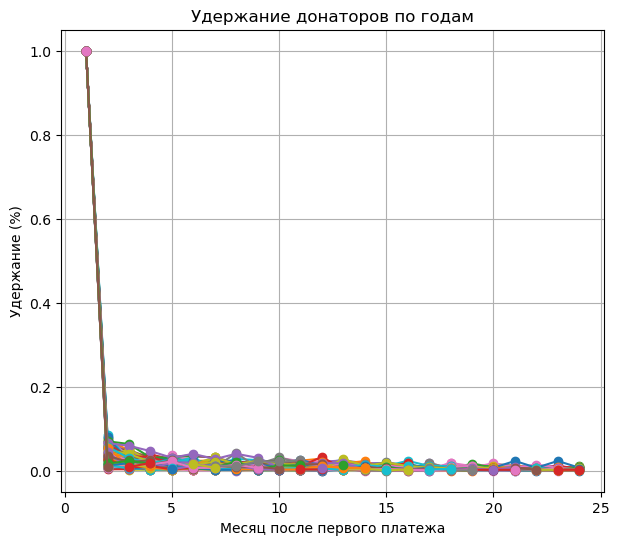

In [103]:
if retention.index.dtype in ['int64', 'float64', 'object']:
    # Преобразуем в строку для отображения
    retention.index = retention.index.astype(str)

# Выбираем колонки с месяцами
month_cols = [col for col in retention.columns if col != 'year']

# Проверяем и корректируем значения
if retention[month_cols].max().max() > 100:
    retention[month_cols] = retentiot[month_cols] / 100

# Группировка по годам (хотя у нас уже по одной строке на год)
retention_by_year = retention.groupby(retention.index)[month_cols].mean().T

# Ограничиваем первыми 24 месяцами
retention_by_year = retention_by_year.loc[:24]

# График
plt.figure(figsize=(7,6))
for year in retention_by_year.columns:
    plt.plot(retention_by_year.index, retention_by_year[year], marker='o', label=year)

plt.title('Удержание донаторов по годам')
plt.xlabel('Месяц после первого платежа')
plt.ylabel('Удержание (%)')
plt.grid(True)
plt.show()

In [104]:
# Churn Rate

In [105]:
df["конец_жизни"] = df["дата/время_последнего_платежа"].fillna(df["дата/время_создания"])

# живые подписки ещё не кончились: их "конец" - это дата среза данных
df.loc[alive, "конец_жизни"] = CUTOFF
df["жива_на_срезе"] = alive

In [106]:
def calculate_monthly_churn_correct(df):
    """
     Расчет месячного churn rate:
    активны в начале месяца → сколько потеряли к концу месяца
    
    Принцип: активны в M5 → сколько потеряли к M6
    """
    # Создаем когорты по месяцам
    df['когорта'] = df['дата/время_создания'].dt.to_period('M')
    df['месяц_жизни'] = ((df['конец_жизни'] - df['дата/время_создания']).dt.days / 30).astype(int)
    
    churn_data = []
    
    for cohort, group in df.groupby('когорта'):
        # Максимальный месяц для этой когорты
        max_month = group['месяц_жизни'].max()
        
        # Проходим по каждому месяцу
        for month in range(1, max_month + 1):
            # Активны В НАЧАЛЕ месяца M (прожили >= month-1 месяцев)
            active_start = (group['месяц_жизни'] >= month - 1).sum()
            
            # Активны В КОНЦЕ месяца M (прожили >= month месяцев)
            active_end = (group['месяц_жизни'] >= month).sum()
            
            # Те, кто ушел В ТЕЧЕНИЕ месяца M
            churned = active_start - active_end
            
            if active_start > 0:
                churn_rate = churned / active_start * 100
                churn_data.append({
                    'когорта': cohort,
                    'месяц': month,
                    'active_start': active_start,
                    'active_end': active_end,
                    'churned': churned,
                    'churn_rate': churn_rate
                })
    
    return pd.DataFrame(churn_data)
    
churn_df_correct = calculate_monthly_churn_correct(df)
print("РАСЧЕТ МЕСЯЧНОГО CHURN RATE")
print("\nПринцип: активны в начале месяца → сколько потеряли к концу месяца")
print("Пример: активны в M5 → сколько потеряли к M6\n")
print(churn_df_correct.head(10))

РАСЧЕТ МЕСЯЧНОГО CHURN RATE

Принцип: активны в начале месяца → сколько потеряли к концу месяца
Пример: активны в M5 → сколько потеряли к M6

   когорта  месяц  active_start  active_end  churned  churn_rate
0  2019-04      1           556         279      277   49.820144
1  2019-04      2           279         173      106   37.992832
2  2019-04      3           173         129       44   25.433526
3  2019-04      4           129          97       32   24.806202
4  2019-04      5            97          79       18   18.556701
5  2019-04      6            79          67       12   15.189873
6  2019-04      7            67          57       10   14.925373
7  2019-04      8            57          54        3    5.263158
8  2019-04      9            54          46        8   14.814815
9  2019-04     10            46          40        6   13.043478


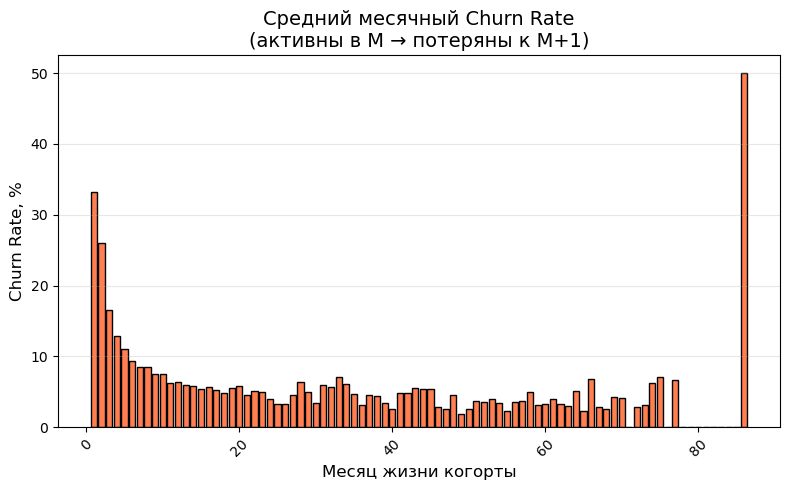

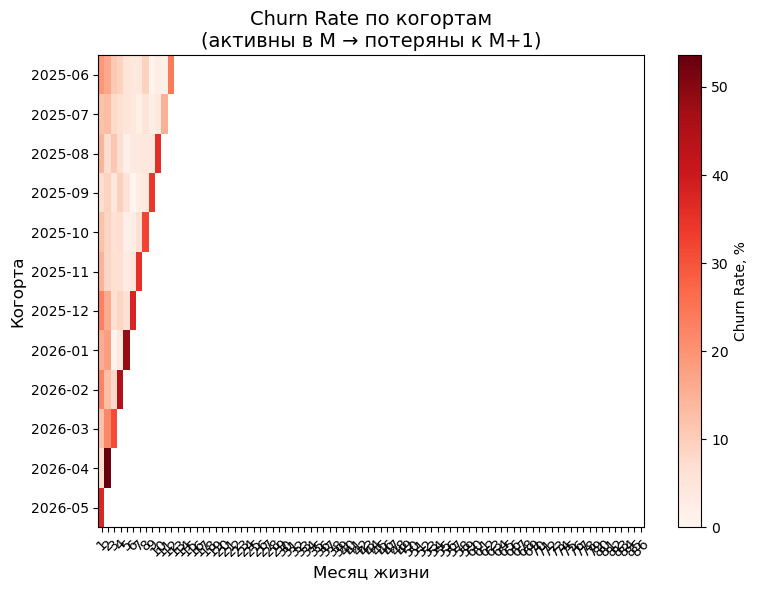

In [107]:
monthly_avg = churn_df_correct.groupby('месяц')['churn_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))

# Столбцы
ax.bar(monthly_avg['месяц'], monthly_avg['churn_rate'], 
       color='coral', edgecolor='black')

ax.set_xlabel('Месяц жизни когорты', fontsize=12)
ax.set_ylabel('Churn Rate, %', fontsize=12)
ax.set_title('Средний месячный Churn Rate\n(активны в M → потеряны к M+1)', fontsize=14)

ax.tick_params(axis='x', labelrotation=45)
# plt.xticks(rotation=45)
# Сетка
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Тепловая карта 

pivot_churn = churn_df_correct.pivot(index='когорта', columns='месяц', values='churn_rate')
pivot_churn = pivot_churn.tail(12)
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot_churn.values, aspect='auto', cmap='Reds')

ax.set_xticks(range(len(pivot_churn.columns)))
ax.set_xticklabels(pivot_churn.columns, rotation=45)
ax.set_yticks(range(len(pivot_churn.index)))
ax.set_yticklabels(pivot_churn.index)
ax.set_xlabel('Месяц жизни', fontsize=12)
ax.set_ylabel('Когорта', fontsize=12)
ax.set_title('Churn Rate по когортам\n(активны в M → потеряны к M+1)', fontsize=14)
plt.colorbar(im, ax=ax, label='Churn Rate, %')
plt.tight_layout()
plt.show()

Самый критический период - первый месяц после оформления подписки.

In [108]:
# Lifetime Value (LTV)

In [109]:
# Общая выручка
total_revenue = df['real_revenue'].sum()

# Все уникальные создатели подписки
total_creators = df['id_плательщика'].nunique()

# Только те, у кого был хотя бы один платёж > 0
paid_creators = df[df['real_revenue'] > 0]['id_плательщика'].nunique()

# Value per subscription creator (включая нулевиков)
ltv_per_creator = total_revenue / total_creators

# Value per paid donor (только платившие)
ltv_per_paid_donor = total_revenue / paid_creators

print(f"Value per subscription creator (все создатели): {ltv_per_creator:.2f} руб.")
print(f"Value per paid donor (только платившие):   {ltv_per_paid_donor:.2f} руб.")
print(f"Доля платящих: {paid_creators / total_creators * 100:.1f}%")
print(f"Разница между показателями: {ltv_per_paid_donor / ltv_per_creator:.1f}x")

Value per subscription creator (все создатели): 2383.19 руб.
Value per paid donor (только платившие):   3390.47 руб.
Доля платящих: 70.3%
Разница между показателями: 1.4x


## 3.8. Выполним ABC-анализ и Pareto-анализ, определим вклад крупнейших донаторов в общий объем пожертвований.

In [110]:
# Рассчитаем общую сумму пожертвований для каждого донатора
donor_revenue = df.groupby('id_плательщика').agg(
    total_revenue=('real_revenue', 'sum'),  # real_revenue = сумма * кол-во_платежей
    frequency=('кол-во_платежей', 'count')
).reset_index()

# Фильтруем только донаторов с платежами (>0)
donor_revenue = donor_revenue[donor_revenue['total_revenue'] > 0]

# Сортируем по убыванию суммы пожертвований
donor_revenue = donor_revenue.sort_values('total_revenue', ascending=False).reset_index(drop=True)
print(f"Всего донаторов с платежами: {len(donor_revenue)}")

Всего донаторов с платежами: 21864


In [111]:
# ABC-анализ (правило Парето: A - 80%, B - 15%, C - 5%)
# Рассчитываем накопленный процент донаторов и накопленный процент выручки
donor_revenue['cumulative_donors_pct'] = (donor_revenue.index + 1) / len(donor_revenue) * 100
donor_revenue['cumulative_revenue'] = donor_revenue['total_revenue'].cumsum()
donor_revenue['cumulative_revenue_pct'] = donor_revenue['cumulative_revenue'] / donor_revenue['total_revenue'].sum() * 100

# Определяем границы групп по накопленному проценту выручки (правило 80/15/5)
total_revenue = donor_revenue['total_revenue'].sum()

# Группа A: донаторы, которые приносят 80% выручки
group_a_threshold = 80
group_a = donor_revenue[donor_revenue['cumulative_revenue_pct'] <= group_a_threshold]
pct_donors_a = (len(group_a) / len(donor_revenue)) * 100

# Группа B: донаторы, которые приносят следующие 15% выручки (80% → 95%)
group_b_threshold = 95
group_b = donor_revenue[(donor_revenue['cumulative_revenue_pct'] > group_a_threshold) & 
                        (donor_revenue['cumulative_revenue_pct'] <= group_b_threshold)]
pct_donors_b = (len(group_b) / len(donor_revenue)) * 100

# Группа C: оставшиеся донаторы (последние 5% выручки)
group_c = donor_revenue[donor_revenue['cumulative_revenue_pct'] > group_b_threshold]
pct_donors_c = (len(group_c) / len(donor_revenue)) * 100

# Расчет границ сумм для каждой группы
min_revenue_a = group_a['total_revenue'].min()
max_revenue_a = group_a['total_revenue'].max()

min_revenue_b = group_b['total_revenue'].min()
max_revenue_b = group_b['total_revenue'].max()

min_revenue_c = group_c['total_revenue'].min()
max_revenue_c = group_c['total_revenue'].max()

print("ABC-АНАЛИЗ ДОНАТОРОВ (Правило 80/15/5)")
print(f"\nГРУППА A (крупные донаторы):")
print(f"  → {pct_donors_a:.1f}% донаторов приносят {group_a_threshold:.0f}% выручки")
print(f"  → Диапазон сумм: {min_revenue_a:,.0f} - {max_revenue_a:,.0f} руб.")
print(f"  → Количество донаторов: {len(group_a):,}")
print(f"  → Сумма выручки: {group_a['total_revenue'].sum():,.2f} руб.")

print(f"\nГРУППА B (средние донаторы):")
print(f"  → {pct_donors_b:.1f}% донаторов приносят {group_b_threshold - group_a_threshold:.0f}% выручки")
print(f"  → Диапазон сумм: {min_revenue_b:,.0f} - {max_revenue_b:,.0f} руб.")
print(f"  → Количество донаторов: {len(group_b):,}")
print(f"  → Сумма выручки: {group_b['total_revenue'].sum():,.2f} руб.")

print(f"\nГРУППА C (мелкие донаторы):")
print(f"  → {pct_donors_c:.1f}% донаторов приносят {100 - group_b_threshold:.0f}% выручки")
print(f"  → Диапазон сумм: {min_revenue_c:,.0f} - {max_revenue_c:,.0f} руб.")
print(f"  → Количество донаторов: {len(group_c):,}")
print(f"  → Сумма выручки: {group_c['total_revenue'].sum():,.2f} руб.")
print(f"ИТОГО донаторов: {len(donor_revenue):,}")
print(f"ИТОГО выручка: {total_revenue:,.2f} руб.")

ABC-АНАЛИЗ ДОНАТОРОВ (Правило 80/15/5)

ГРУППА A (крупные донаторы):
  → 24.7% донаторов приносят 80% выручки
  → Диапазон сумм: 3,300 - 235,500 руб.
  → Количество донаторов: 5,411
  → Сумма выручки: 59,300,956.00 руб.

ГРУППА B (средние донаторы):
  → 28.4% донаторов приносят 15% выручки
  → Диапазон сумм: 950 - 3,300 руб.
  → Количество донаторов: 6,207
  → Сумма выручки: 11,121,512.00 руб.

ГРУППА C (мелкие донаторы):
  → 46.9% донаторов приносят 5% выручки
  → Диапазон сумм: 1 - 950 руб.
  → Количество донаторов: 10,246
  → Сумма выручки: 3,706,785.82 руб.
ИТОГО донаторов: 21,864
ИТОГО выручка: 74,129,253.82 руб.


In [112]:
# Pareto-анализ (Закон 80/20)
# Находим донаторов, которые приносят 80% выручки
pareto_threshold = 80
pareto_donors = donor_revenue[donor_revenue['cumulative_revenue_pct'] <= pareto_threshold]
pct_donors_pareto = (len(pareto_donors) / len(donor_revenue)) * 100
pct_revenue_pareto = pareto_donors['total_revenue'].sum() / total_revenue * 100
print("PARETO - анализ (Закон 80/20)")
print(f"{pct_donors_pareto:.1f}% донаторов приносят {pct_revenue_pareto:.1f}% выручки")
print(f"Количество донаторов в топ-{pareto_threshold}%: {len(pareto_donors)}")
print(f"Сумма выручки: {pareto_donors['total_revenue'].sum():,.2f} руб.")

PARETO - анализ (Закон 80/20)
24.7% донаторов приносят 80.0% выручки
Количество донаторов в топ-80%: 5411
Сумма выручки: 59,300,956.00 руб.


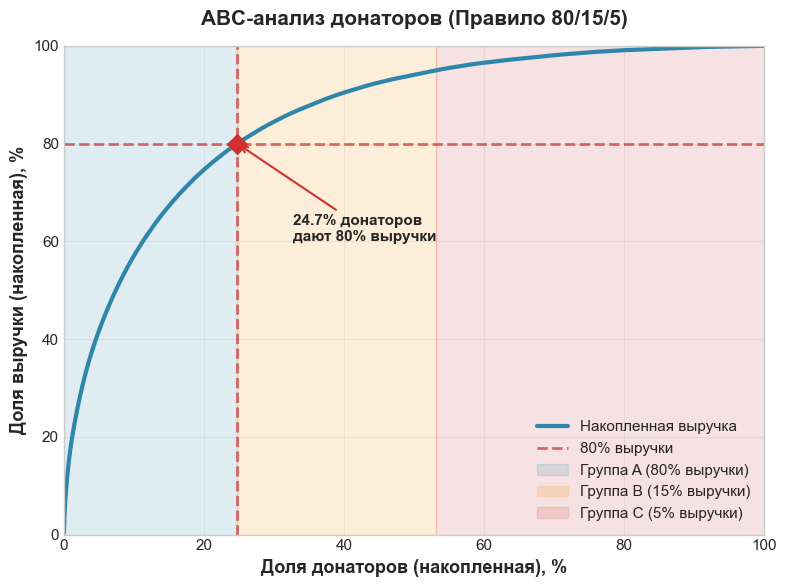

<Figure size 640x480 with 0 Axes>

ИТОГИ ABC-АНАЛИЗА (Правило 80/15/5)
Группа     Доля донаторов       Доля выручки         Средний чек     Кол-во    
A            24.7%               80.0%                      10,959 руб.    5,411
B            28.4%               15.0%                       1,792 руб.    6,207
C            46.9%               5.0%                          362 руб.   10,246
ИТОГО      100.0%               100.0%                      3,390 руб.   21,864

 PARETO-АНАЛИЗ (Закон 80/20):
  → 24.7% донаторов приносят 80% выручки
  → Количество донаторов в топ-80%: 5,411
  → Сумма выручки: 59,300,956.00 руб.


In [113]:
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['font.size'] = 11
plt.rcParams['figure.dpi'] = 100

# КРИВАЯ ПАРЕТО (Накопленная выручка)
fig, ax = plt.subplots(figsize=(8, 6))

# Основная кривая
ax.plot(donor_revenue['cumulative_donors_pct'], 
        donor_revenue['cumulative_revenue_pct'], 
        color='#2E86AB', linewidth=3, label='Накопленная выручка')
# Линия 80/20
ax.axhline(y=80, color='#D32F2F', linestyle='--', linewidth=2, alpha=0.7, label='80% выручки')
ax.axvline(x=pct_donors_pareto, color='#D32F2F', linestyle='--', linewidth=2, alpha=0.7)
# Зоны ABC
ax.axvspan(0, pct_donors_a, alpha=0.15, color='#2E86AB', label='Группа A (80% выручки)')
ax.axvspan(pct_donors_a, pct_donors_a + pct_donors_b, alpha=0.15, color='#F18F01', label='Группа B (15% выручки)')
ax.axvspan(pct_donors_a + pct_donors_b, 100, alpha=0.15, color='#C73E3E', label='Группа C (5% выручки)')
# Точка пересечения 80/20
ax.scatter(pct_donors_pareto, 80, color='#D32F2F', s=100, zorder=5, marker='D')
ax.annotate(f'{pct_donors_pareto:.1f}% донаторов\nдают 80% выручки',
            xy=(pct_donors_pareto, 80),
            xytext=(pct_donors_pareto + 8, 60),
            fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#D32F2F', lw=1.5))
ax.set_xlabel('Доля донаторов (накопленная), %', fontsize=13, fontweight='bold')
ax.set_ylabel('Доля выручки (накопленная), %', fontsize=13, fontweight='bold')
ax.set_title('ABC-анализ донаторов (Правило 80/15/5)', fontsize=15, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

# Добавляем статистику
stats_text = f"""
Статистика по группам:
Группа A: мин={min_revenue_a:,.0f} | макс={max_revenue_a:,.0f} | медиана={group_a['total_revenue'].median():,.0f}
Группа B: мин={min_revenue_b:,.0f} | макс={max_revenue_b:,.0f} | медиана={group_b['total_revenue'].median():,.0f}
Группа C: мин={min_revenue_c:,.0f} | макс={max_revenue_c:,.0f} | медиана={group_c['total_revenue'].median():,.0f}
"""
ax.text(0.02, 0.95, stats_text, transform=ax.transAxes, fontsize=9,
        verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))
plt.tight_layout()
plt.show()
# ИТОГОВАЯ СВОДКА ПО ABC-АНАЛИЗУ

print("ИТОГИ ABC-АНАЛИЗА (Правило 80/15/5)")
print(f"{'Группа':<10} {'Доля донаторов':<20} {'Доля выручки':<20} {'Средний чек':<15} {'Кол-во':<10}")
print(f"{'A':<10} {pct_donors_a:>6.1f}%{'':<14} {'80.0%':<20} {group_a['total_revenue'].mean():>12,.0f} руб. {len(group_a):>8,}")
print(f"{'B':<10} {pct_donors_b:>6.1f}%{'':<14} {'15.0%':<20} {group_b['total_revenue'].mean():>12,.0f} руб. {len(group_b):>8,}")
print(f"{'C':<10} {pct_donors_c:>6.1f}%{'':<14} {'5.0%':<20} {group_c['total_revenue'].mean():>12,.0f} руб. {len(group_c):>8,}")
print(f"{'ИТОГО':<10} {'100.0%':<20} {'100.0%':<20} {donor_revenue['total_revenue'].mean():>12,.0f} руб. {len(donor_revenue):>8,}")
# Pareto-вывод
print("\n PARETO-АНАЛИЗ (Закон 80/20):")
print(f"  → {pct_donors_pareto:.1f}% донаторов приносят 80% выручки")
print(f"  → Количество донаторов в топ-80%: {len(pareto_donors):,}")
print(f"  → Сумма выручки: {pareto_donors['total_revenue'].sum():,.2f} руб.")

Группа A — ключевые донаторы (24.7% аудитории). Каждый донатор группы А приносит в 3.2 раза больше среднего чека по организации. Всего 1/4 аудитории генерирует 4/5 всей выручки
Требуется VIP-подход: персональные менеджеры, эксклюзивные отчёты, отдельные коммуникации.
Группа B — средние донаторы (28.4% аудитории).Средний чек в 6 раз ниже, чем в группе А. При этом группа B почти равна группе A по численности, но даёт в 5 раз меньше выручки. Потенциал роста: если поднять средний чек группы B до 3,000 руб., дополнительная выручка составит 7.5 млн руб. (+10% к общей выручке).
Группа C — Мелкие донаторы (46.9% аудитории).Самый массовый сегмент — почти половина всех донаторов. Но даёт всего 5% выручки. Средний чек в 30 раз ниже, чем в группе А. Это зона для автоматизации — персональные коммуникации здесь экономически нецелесообразны.

Организация находится в зоне повышенной зависимости от 5,411 ключевых донаторов, но имеет огромный потенциал роста (+15% к выручке) за счёт апсейла в группе B, не привлекая новых пользователей.

## Итоговый вывод

Ключевые проблемы:

Фонд сталкивается с трудностями, которые заключается не в разовых сбоях, а в потере способности привлекать и удерживать донаторов. 

Высокий отток и потеря донаторов: Более 75% донаторов считаются «ушедшими» (не платили более 180 дней). Основная проблема — не в привлечении, а в удержании.

Обвал новых подписок: С конца 2024 года и особенно в 2025-2026 годах количество новых подписок рухнуло. Это указывает на критический провал в маркетинге и привлечении.

Снижение «качества» донаторов: Новые донаторы стали платить меньше (средний чек падает) и отписываться быстрее.

Потеря крупных донаторов: Фонд теряет свою «золотую жилу» — донаторов с высоким чеком, которые обеспечивали львиную долю дохода.

На основе анализа предлагается следующий план действий:

Приоритет №1: Спасти «Ядро» и «Спящих гигантов» (Удержание и Реактивация)
Это самые быстрые и эффективные действия.

Внедрить систему удержания для «Ядра» (активные, 7+ платежей):

Действие: Создать персонализированную коммуникацию. Благодарственные письма от руководства, ежегодные отчеты о достижениях, приглашения на закрытые мероприятия. Им важно чувствовать свою причастность и видеть результат своей помощи.

Цель: Снизить отток в этом сегменте на 10-15% в ближайшие полгода.

Запустить кампанию по возврату «Спящих» донаторов (ушедшие, 7+ платежей):

Действие: Сегментировать эту группу. Отправить им персонализированные письма с «воспоминаниями» об их добрых делах, истории подопечных и предложением вернуться с минимальной суммой. Важно не просто просить денег, а напомнить о ценности их предыдущего вклада.

Цель: Вернуть хотя бы 10% этого сегмента. Это принесет быстрый и значительный прирост дохода.

«Спасти» донаторов в статусе «Просрочена»:

Действие: Настроить автоматическую систему уведомлений (SMS, email) при первой и второй неудачной попытке списания. Предложить простой способ обновить данные карты.

Цель: Предотвратить переход активного донатора в статус «Отклонена» из-за технических проблем.

Приоритет №2: Исправить «Воронку» (Конверсия и Привлечение)
Проблема здесь связана с качеством трафика и процессом оформления.

Улучшить процесс оформления подписки:

Действие: Проанализировать, на каком этапе «отваливаются» донаторы. Упростить форму, добавить больше способов оплаты (например, SBP), улучшить мобильную версию страницы.

Цель: Снизить процент «Не запустившихся» подписок и повысить конверсию из разового пожертвования в регулярное.

Пересмотреть маркетинговую стратегию по привлечению:

Действие: Проанализировать, какие каналы привели самых «живучих» донаторов (из «Ядра»). Сфокусировать бюджет на этих каналах. Прекратить тратить деньги на каналы, привлекающие «однодневок».

Цель: Повысить «качество» (LTV) новых донаторов, а не только их количество.

Запустить программу по конвертации разовых донаторов:

Действие: Разработать email-цепочку для тех, кто сделал разовое пожертвование, с предложением подписаться на регулярное, показав удобство и важность ежемесячной поддержки.

Приоритет №3: Использовать данные для стратегических решений
Настроить систему мониторинга (Дашборд):

Действие: Использовать дашборд для ежемесячного отслеживания ключевых метрик: число активных донаторов в «ядре», количество «просроченных» подписок, объем пожертвований.

Цель: Перейти от реактивного управления к проактивному. Видеть проблемы на ранней стадии (например, рост «Просроченных» в Ядре) и мгновенно реагировать.

Создать «боевой» план на основе сезонности:

Действие: Заранее готовить специальные кампании на «слабые» месяцы (январь, март, август, сентябрь), используя успешные практики из «сильных» месяцев.

Цель: Сгладить сезонные спады и обеспечить более стабильный приток средств.

Главный вывод — удержание ценной аудитории в разы эффективнее, чем привлечение новой. Сосредоточив усилия на возврате и сохранении «ядерных» и «спящих» донаторов, а также устранив технические проблемы с платежами, фонд может стабилизировать свои доходы и создать базу для будущего роста.

## Экспорт витрин для Power BI

Дашборд собирается в Power BI. Расчётные результаты передаются в него готовыми таблицами-витринами, чтобы вся логика анализа оставалась в одном месте — в этом ноутбуке:

- `rfm_данные.csv` — уровень донатора: RFM-категории и ABC-класс для сегментных страниц;
- `когортная_таблица_удержание.csv` — когортная матрица удержания;
- `кривая_выживаемости.csv` — точки кривых Каплана–Майера. 

In [134]:
# Преобразуем матрицу удержания в длинный формат
retention_long = retention.reset_index().melt(
    id_vars='CohortMonth', 
    var_name='CohortIndex', 
    value_name='Retention'
)

# Преобразуем матрицу количества донаторов
counts_long = cohort_counts.reset_index().melt(
    id_vars='CohortMonth', 
    var_name='CohortIndex', 
    value_name='Count'
)

# Добавляем метрику (чтобы различать потом в DataLens)
retention_long['Metric'] = 'Retention (%)'
counts_long['Metric'] = 'Count'

combined_long = pd.concat([retention_long, counts_long], ignore_index=True)

# Заменяем NaN на пустую строку или 0
combined_long = combined_long.fillna('')   # пустая строка

combined_long.to_csv('cohort_combined_long.csv', sep=';', index=False, encoding='utf-8-sig')

C:\Users\Victoria\AppData\Local\Temp\ipykernel_35232\266581845.py:22: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_long = combined_long.fillna('')   # пустая строка


In [132]:
# RFM-метки
payers_export = payers[['платежей', 'сбор', 'R_дней', 'R', 'F', 'M']].copy()
payers_export.to_csv('rfm_данные_донаторов.csv', encoding='utf-8-sig')
print("Сохранено: rfm_данные.csv")

Сохранено: rfm_данные.csv


In [133]:
# Кривая выживаемости 
survival_table = kmf.survival_function_.reset_index()
survival_table.columns = ['дней', 'выживаемость']
survival_table.to_csv('кривая_выживаемости.csv', index=False, encoding='utf-8-sig')
print("Сохранено: кривая_выживаемости.csv")

Сохранено: кривая_выживаемости.csv
